In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

RUTA = Path("/content/drive/MyDrive/Laboratorio Física Contemporánea I/Práctica 2 - Tierras raras/Datos")

$$ E = \frac{10^7}{\lambda}$$

La $E$ está en $cm^{-1}$ y la lambda en $nm$.

In [ ]:
# Definimos una función para calcular el valor máximo y mínimo de la longitud de onda del pico
# (a partir de la mitad de la intensidad del pico); esta anchura del pico será la incertidumbre
def ancho_pico(base_datos,mitad_intesidad):
    # Valores estrictamente menores y mayores
    menores = base_datos[base_datos["y"] < mitad_intesidad]
    mayores = base_datos[base_datos["y"] > mitad_intesidad]

    # Comprobamos que existan vecinos a ambos lados
    if menores.empty:
        raise ValueError("No existe un valor de y anterior al buscado.")

    if mayores.empty:
        raise ValueError("No existe un valor de y posterior al buscado.")

    # Índice del y más cercano por debajo
    idx_antes = menores["y"].idxmax()
    # Índice del y más cercano por arriba
    idx_despues = mayores["y"].idxmin()

    # Filas completas
    antes = base_datos.loc[idx_antes]
    despues = base_datos.loc[idx_despues]

    # Valores por separado
    x_antes = antes["x"]
    y_antes = antes["y"]

    x_despues = despues["x"]
    y_despues = despues["y"]

    # Construimos una tabla con los resultados
    resultado = pd.DataFrame({
            "posición": [idx_antes, idx_despues],
            "Lambda": [x_antes, x_despues],
            "Intensidad": [y_antes, y_despues]},
            index=["antes", "después"] )

    return resultado, x_antes, y_antes, x_despues, y_despues

In [ ]:
# Definimos una función para calcular la energía

def energia(longitud_onda,incertidumbre_long_onda):
    E = (1e7)/longitud_onda
    E_min = (1e7)/(longitud_onda+incertidumbre_long_onda)
    E_max = (1e7)/(longitud_onda-incertidumbre_long_onda)
    inc_E = abs(E_max - E_min)
    return print("Eergía correspondiente",f"{E:.2f}",'±',f"{inc_E:.2f}")

<hr style="border: 5px solid #000;">

### **Configuración para calcular los niveles de energía**

<hr style="border: 5px solid #000;">

#### Configuración de todo

Se usó la biblioteca Dieke ([página](https://dieke.readthedocs.io/en/latest/prlaf3example.html)) y con ayuda de ChatGPT se configuró la base de datos que faltaba. Para "comprobar" que los datos son bueno, se hizo el diagrama de Dieke y se comparó con el del la web para ver que fueran consistentes.

Una vez hecho esto, se programó una función para obtener todas las posibles transiciones de energía dado una longitud de onda (los picos que identificamos en cada elemento).

In [ ]:
%pip install dieke==0.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00


In [ ]:
from scipy.sparse import issparse
from fractions import Fraction
from IPython.display import display

import dieke

Definimos los tres iones a configurar:

$ \mathrm{Pr}^{3+}:4f^2,\qquad \mathrm{Eu}^{3+}:4f^6, \qquad \mathrm{Tb}^{3+}:4f^8$

In [ ]:
IONES = {
    "Pr3+": 2,
    "Eu3+": 6,
    "Tb3+": 8,
    "Sm3+": 5,
    "Dy3+": 9 }

A mano metemos los datos del $Pr$ y el $Eu$ ya que no se encuentran en la biblioteca Dieke. Estos datos fueron obtenidos de https://digital.library.unt.edu/ark:/67531/metadc282858/m1/ .

In [ ]:
PARAMETROS_CARNALL = {
    "Pr3+": {
        "F2": 68878.0,
        "F4": 50347.0,
        "F6": 32901.0,
        "ZETA": 751.7,
        "ALPHA": 16.23,
        "BETA": -566.6,
        "GAMMA": 1371.0,
        "M0": 2.08,
        "P2": -88.6,},

    "Eu3+": {
        "F2": 83125.0,
        "F4": 59268.0,
        "F6": 42560.0,
        "ZETA": 1338.0,
        "ALPHA": 20.16,
        "BETA": -566.9,
        "GAMMA": 1500.0,
        "M0": 2.10,
        "P2": 360.0,},

    "Tb3+": {
        "F2": 88995.0,
        "F4": 62919.0,
        "F6": 47252.0,
        "ZETA": 1707.0,
        "ALPHA": 18.40,
        "BETA": -590.9,
        "GAMMA": 1650.0,
        "M0": 2.39,
        "P2": 373.0,},

    "Sm3+": {
        "F2": 79805.0,
        "F4": 57175.0,
        "F6": 40250.0,
        "ZETA": 1176.0,
        "ALPHA": 20.16,
        "BETA": -566.9,
        "GAMMA": 1500.0,
        "M0": 2.60,
        "P2": 357.0,},

    "Dy3+": {
        "F2": 91903.0,
        "F4": 64372.0,
        "F6": 49386.0,
        "ZETA": 1913.0,
        "ALPHA": 18.02,
        "BETA": -633.4,
        "GAMMA": 1790.0,
        "M0": 3.39,
        "P2": 719.0,} }

In [ ]:
def completar_parametros_dieke(params):
    p = params.copy()

    if "M0" in p:
        p["M2"] = 0.56 * p["M0"]
        p["M4"] = 0.31 * p["M0"]

    if "P2" in p:
        p["P4"] = 0.5 * p["P2"]
        p["P6"] = 0.1 * p["P2"]

    return p


PARAMETROS_CARNALL = {
    ion: completar_parametros_dieke(params)
    for ion, params in PARAMETROS_CARNALL.items() }

In [ ]:
# Comprobamos
for ion, params in PARAMETROS_CARNALL.items():
    print(f"\n{ion}")
    for nombre, valor in params.items():
        print(f"{nombre:6s} = {valor}")


Pr3+
F2     = 68878.0
F4     = 50347.0
F6     = 32901.0
ZETA   = 751.7
ALPHA  = 16.23
BETA   = -566.6
GAMMA  = 1371.0
M0     = 2.08
P2     = -88.6
M2     = 1.1648
M4     = 0.6448
P4     = -44.3
P6     = -8.86

Eu3+
F2     = 83125.0
F4     = 59268.0
F6     = 42560.0
ZETA   = 1338.0
ALPHA  = 20.16
BETA   = -566.9
GAMMA  = 1500.0
M0     = 2.1
P2     = 360.0
M2     = 1.1760000000000002
M4     = 0.651
P4     = 180.0
P6     = 36.0

Tb3+
F2     = 88995.0
F4     = 62919.0
F6     = 47252.0
ZETA   = 1707.0
ALPHA  = 18.4
BETA   = -590.9
GAMMA  = 1650.0
M0     = 2.39
P2     = 373.0
M2     = 1.3384000000000003
M4     = 0.7409
P4     = 186.5
P6     = 37.300000000000004

Sm3+
F2     = 79805.0
F4     = 57175.0
F6     = 40250.0
ZETA   = 1176.0
ALPHA  = 20.16
BETA   = -566.9
GAMMA  = 1500.0
M0     = 2.6
P2     = 357.0
M2     = 1.4560000000000002
M4     = 0.806
P4     = 178.5
P6     = 35.7

Dy3+
F2     = 91903.0
F4     = 64372.0
F6     = 49386.0
ZETA   = 1913.0
ALPHA  = 18.02
BETA   = -633.4
GAMMA  = 17

Definimos funciones para los cálculos.

In [ ]:
# Definimos primero una función para convertir matrices sparse en matrices normales de NumPy
def a_densa(A):
    if issparse(A):
        return A.toarray()

    return np.asarray(A)

# Definimos después una función para escribir correctamente valores como J = 5/2, 7/2, ...
def formato_J(J):
    f = Fraction(float(J)).limit_denominator(2)

    if f.denominator == 1:
        return str(f.numerator)

    return f"{f.numerator}/{f.denominator}"

# Definimos la notación espectroscópica
LETRAS_L = "SPDFGHIKLMNOQRT"

In [ ]:
# Construcción y diagonalización del hamiltoniano

def calcular_multipletes(nombre_ion, nf):
    # Base LSJ del ion
    ion = dieke.IsotropicRareEarthIon(nf)
    # Parámetros espectroscópicos
    params = PARAMETROS_CARNALL[nombre_ion]
    N = ion.numlevels()
    # Hamiltoniano inicialmente nulo
    H = np.zeros((N, N), dtype=complex)
    parametros_usados = []

    # Construcción de H_FI
    for nombre_parametro, valor in params.items():
        if nombre_parametro in ion.FreeIonMatrix:
            matriz = a_densa(
                ion.FreeIonMatrix[nombre_parametro] )
            H += valor * matriz
            parametros_usados.append(nombre_parametro)

    # Evita repetir el problema anterior de Eu y Tb
    if len(parametros_usados) == 0:
        raise ValueError(
            f"No se pudo construir el Hamiltoniano para {nombre_ion}." )

    # Garantizamos hermiticidad numérica
    H = (H + H.conj().T) / 2
    # Diagonalización
    energias, vectores = np.linalg.eigh(H)
    # Ordenamos por energía
    orden = np.argsort(energias.real)
    energias = energias.real[orden]
    vectores = vectores[:, orden]
    # Tomamos el estado fundamental como E = 0
    energias -= energias.min()
    filas = []

    # Identificamos el carácter LSJ dominante
    for i, E in enumerate(energias):
        pesos = np.abs(vectores[:, i])**2
        indice_principal = np.argmax(pesos)
        etiqueta_cruda = ion.LSJlevelLabels[indice_principal]
        S = dieke.SfromLevelLabel(etiqueta_cruda)
        L = dieke.LfromLevelLabel(etiqueta_cruda)
        J = dieke.JfromLevelLabel(etiqueta_cruda)
        multiplicidad = int(round(2*S + 1))
        termino = (
            f"{multiplicidad}"
            f"{LETRAS_L[L]}"
            f"_{formato_J(J)}" )

        filas.append({
            "ion": nombre_ion,
            "nf": nf,
            "E_cm-1": E,
            "termino": termino,
            "J": J,
            "peso_principal": pesos[indice_principal],
            "etiqueta_dieke": etiqueta_cruda.strip() })

    df = pd.DataFrame(filas)

    return df, parametros_usados

Calculamos ahora sí nuestra base de niveles

In [ ]:
tablas = []

for nombre, nf in IONES.items():
    df_ion, params_usados = calcular_multipletes(
        nombre,
        nf )

    tablas.append(df_ion)

    print(f"\n{nombre}")
    print(f"Número de multipletes LSJ: {len(df_ion)}")
    print("Parámetros usados:")
    print(params_usados)

niveles = pd.concat(
    tablas,
    ignore_index=True )


Pr3+
Número de multipletes LSJ: 13
Parámetros usados:
['F2', 'F4', 'F6', 'ZETA', 'ALPHA', 'BETA', 'GAMMA', 'M0', 'P2', 'M2', 'M4', 'P4', 'P6']

Eu3+
Número de multipletes LSJ: 295
Parámetros usados:
['F2', 'F4', 'F6', 'ZETA', 'ALPHA', 'BETA', 'GAMMA', 'M0', 'P2', 'M2', 'M4', 'P4', 'P6']

Tb3+
Número de multipletes LSJ: 295
Parámetros usados:
['F2', 'F4', 'F6', 'ZETA', 'ALPHA', 'BETA', 'GAMMA', 'M0', 'P2', 'M2', 'M4', 'P4', 'P6']

Sm3+
Número de multipletes LSJ: 198
Parámetros usados:
['F2', 'F4', 'F6', 'ZETA', 'ALPHA', 'BETA', 'GAMMA', 'M0', 'P2', 'M2', 'M4', 'P4', 'P6']

Dy3+
Número de multipletes LSJ: 198
Parámetros usados:
['F2', 'F4', 'F6', 'ZETA', 'ALPHA', 'BETA', 'GAMMA', 'M0', 'P2', 'M2', 'M4', 'P4', 'P6']


In [ ]:
# Lo visualizamos
niveles

,ion,nf,E_cm-1,termino,J,peso_principal,etiqueta_dieke
0,Pr3+,2,0.000000,3H_4,4.0,0.971414,1 3H 4
1,Pr3+,2,2085.628644,3H_5,5.0,1.000000,1 3H 5
2,Pr3+,2,4257.601863,3H_6,6.0,0.996993,1 3H 6
3,Pr3+,2,4895.093843,3F_2,2.0,0.976237,1 3F 2
4,Pr3+,2,6284.451465,3F_3,3.0,1.000000,1 3F 3
...,...,...,...,...,...,...,...
994,Dy3+,9,123716.794113,2H_9/2,4.5,0.512992,2 2H 9/2
995,Dy3+,9,139892.768020,2D_5/2,2.5,0.550542,2 2D 5/2
996,Dy3+,9,144329.757333,2D_3/2,1.5,0.583352,2 2D 3/2
997,Dy3+,9,144622.284984,2F_7/2,3.5,0.668757,1 2F 7/2


In [ ]:
for ion in ["Pr3+", "Eu3+", "Tb3+", "Sm3+", "Dy3+"]:
    df = niveles[niveles["ion"] == ion]
    print(f"\n{ion}")
    print(f"E mínima = "f"{df['E_cm-1'].min():.2f} cm^-1" )
    print(f"E máxima = "f"{df['E_cm-1'].max():.2f} cm^-1" )
    print("Número de energías distintas =",df["E_cm-1"].round(6).nunique())


Pr3+
E mínima = 0.00 cm^-1
E máxima = 46699.13 cm^-1
Número de energías distintas = 13

Eu3+
E mínima = 0.00 cm^-1
E máxima = 177822.68 cm^-1
Número de energías distintas = 295

Tb3+
E mínima = 0.00 cm^-1
E máxima = 190650.70 cm^-1
Número de energías distintas = 295

Sm3+
E mínima = 0.00 cm^-1
E máxima = 125829.35 cm^-1
Número de energías distintas = 198

Dy3+
E mínima = 0.00 cm^-1
E máxima = 147535.99 cm^-1
Número de energías distintas = 198


Finalmente, hacemos la gráfica del diagrama de Dieke

In [ ]:
def diagrama_dieke(df,Emax=40000):
    orden_iones = [
        "Pr3+",
        "Eu3+",
        "Tb3+",
        "Sm3+",
        "Dy3+" ]

    fig, ax = plt.subplots(figsize=(12, 10))

    for x, nombre in enumerate(orden_iones):
        datos = df[(df["ion"] == nombre) & (df["E_cm-1"] <= Emax)]

        for E in datos["E_cm-1"]:
            ax.hlines(E,x - 0.30,x + 0.30)

    ax.set_xticks(range(len(orden_iones)),orden_iones)
    ax.set_xlim(-0.6,len(orden_iones) - 0.4)
    ax.set_ylim(0,Emax)
    ax.set_ylabel(r"Energía espectroscópica (cm$^{-1}$)")
    ax.set_title(r"Multipletes $4f^N$ de Pr$^{3+}$, Eu$^{3+}$, Tb$^{3+}$, Sm$^{3+}$ y Dy$^{3+}$")
    ax.grid(axis="y",alpha=0.2)
    plt.show()

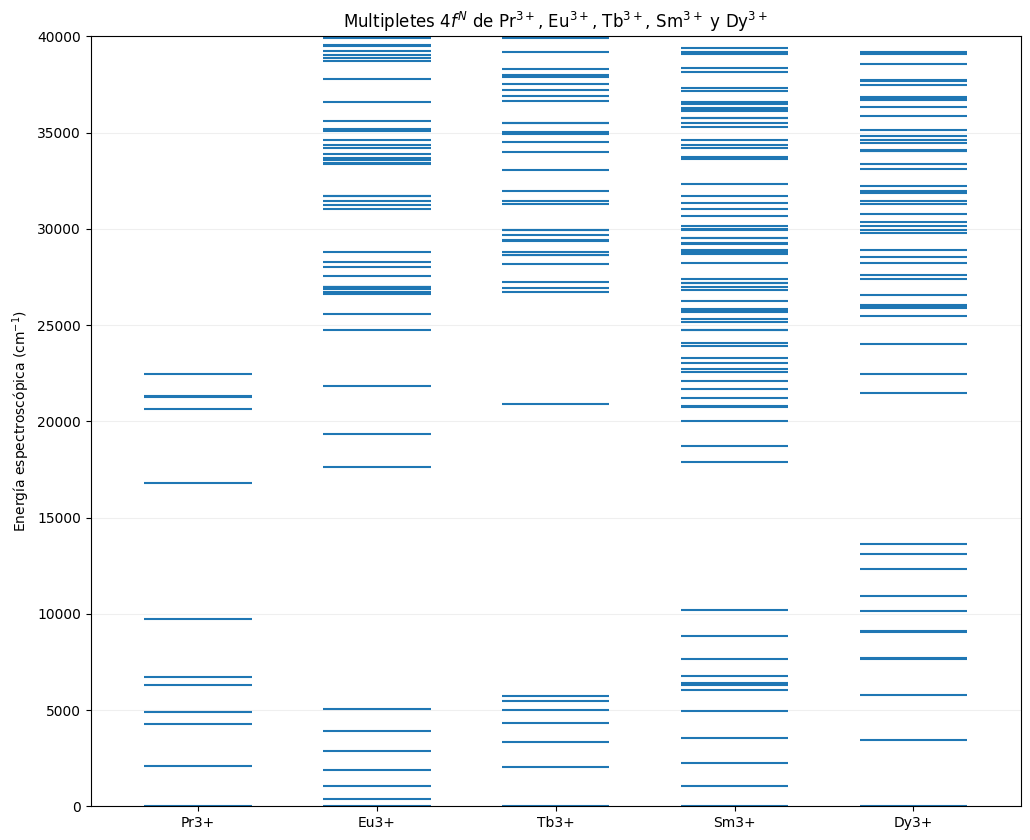

In [ ]:
diagrama_dieke(niveles,Emax=40000)

Con etiquetas:

In [ ]:
def diagrama_dieke_etiquetas(df,Emax=40000):
    orden_iones = ["Pr3+","Eu3+","Tb3+","Sm3+","Dy3+"]
    fig, ax = plt.subplots(figsize=(12,20))

    for x, nombre in enumerate(orden_iones):
        datos = (df[(df["ion"] == nombre) & (df["E_cm-1"] <= Emax)].sort_values("E_cm-1"))

        for _, fila in datos.iterrows():
            E = fila["E_cm-1"]
            etiqueta = fila["termino"]
            ax.hlines(E,x - 0.25,x + 0.25)
            ax.text(x + 0.28,E,etiqueta,va="center",fontsize=7)

    ax.set_xticks(range(len(orden_iones)),orden_iones)
    ax.set_xlim(-0.6,len(orden_iones) - 0.1)
    ax.set_ylim(0,Emax)
    ax.set_ylabel(r"Energía espectroscópica (cm$^{-1}$)")
    ax.set_title(r"Multipletes $4f^N$ de Pr$^{3+}$, Eu$^{3+}$, Tb$^{3+}$, Sm$^{3+}$ y Dy$^{3+}$ con etiquetas")
    ax.grid(axis="y",alpha=0.2)
    plt.show()

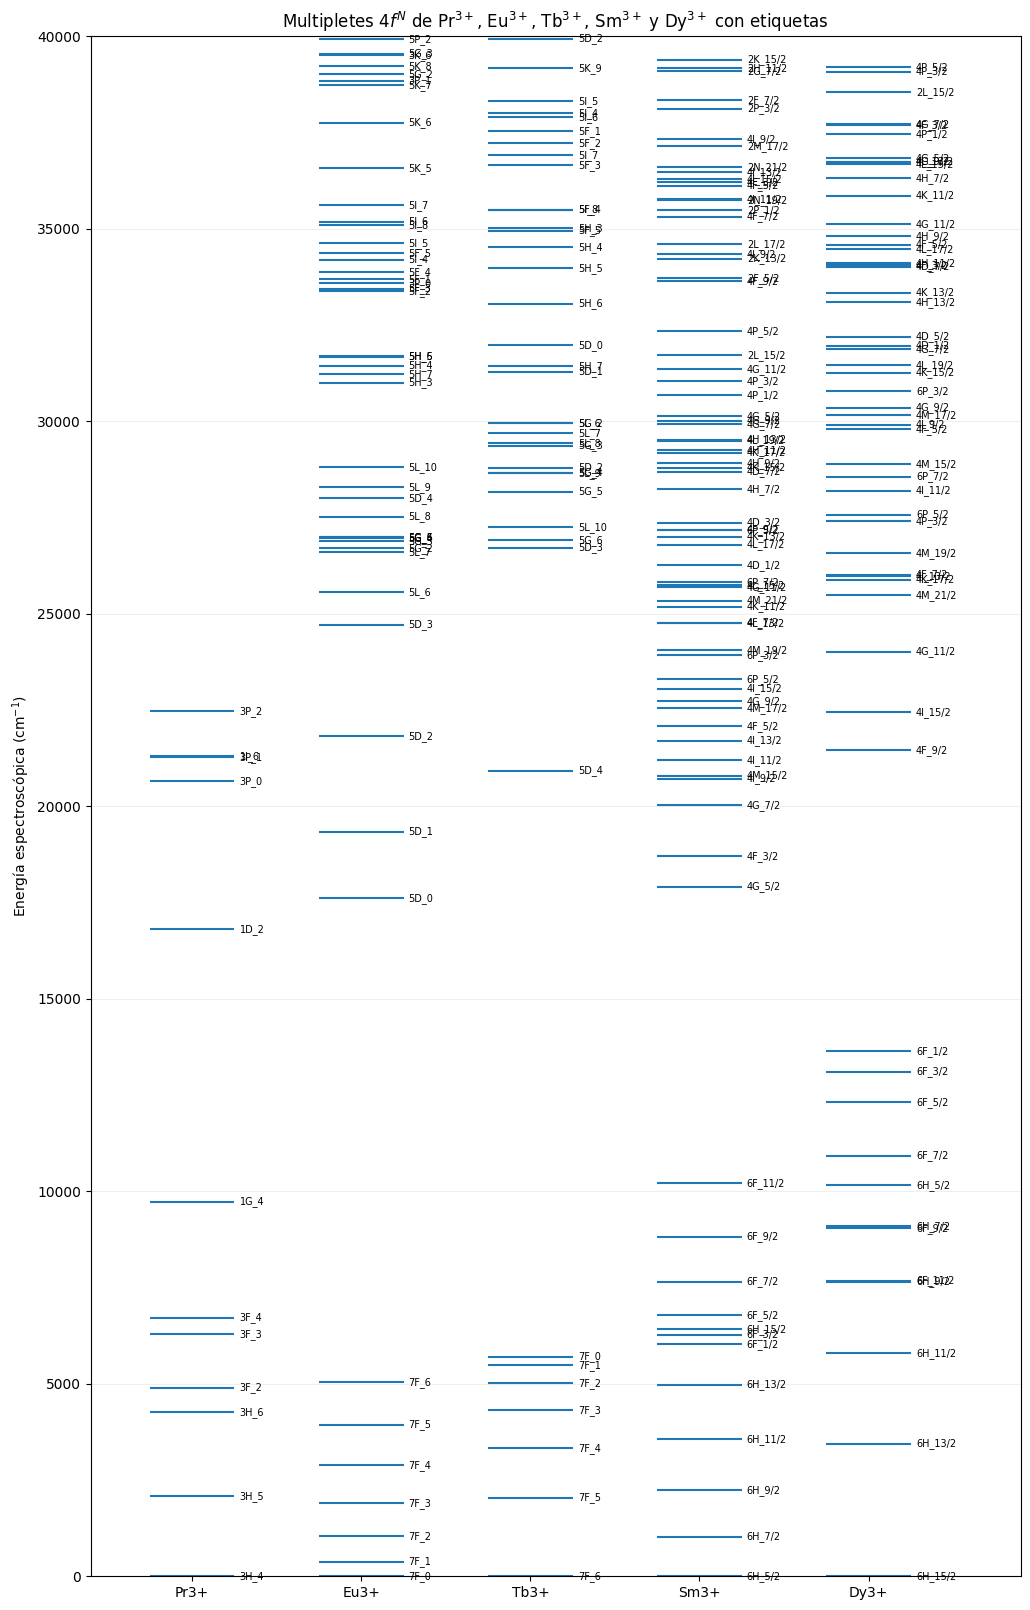

In [ ]:
diagrama_dieke_etiquetas(niveles, Emax=40000)

Hacemos unas últimas funciones para enlistar las posibles energías de transición, dada la energía calculada con el pico que encontré.

In [246]:
def buscar_transiciones(E_obs,ion,niveles,E_menos=None,E_mas=None,Emax=40000):
    datos = (niveles[(niveles["ion"] == ion) & (niveles["E_cm-1"] <= Emax)].sort_values("E_cm-1").reset_index(drop=True))

    if len(datos) == 0:
        raise ValueError(f"No se encontró el ion {ion}.")

    # Si no das incertidumbre, busca solamente por cercanía
    if E_menos is None:
        E_menos = E_obs

    if E_mas is None:
        E_mas = E_obs

    candidatos = []

    for i in range(len(datos)):
        Ei = datos.loc[i, "E_cm-1"]

        for j in range(i):
            Ef = datos.loc[j, "E_cm-1"]
            delta_E = Ei - Ef

            if E_menos <= delta_E <= E_mas:
                candidatos.append({
                    "estado_i": datos.loc[i, "termino"],
                    "Ei_cm-1": Ei,
                    "estado_f": datos.loc[j, "termino"],
                    "Ef_cm-1": Ef,
                    "DeltaE_cm-1": delta_E,
                    "lambda_calc_nm": 1e7 / delta_E,
                    "residuo_cm-1": delta_E - E_obs})

    resultado = pd.DataFrame(candidatos)

    if len(resultado) == 0:
        return resultado

    resultado["error_abs_cm-1"] = (resultado["residuo_cm-1"].abs())

    return (resultado.sort_values("error_abs_cm-1").reset_index(drop=True))

Configuración para la gráfica del análisis:

In [247]:
# Definimos una función para graficar un solo ion y trazar manualmente transiciones
def diagrama_dieke_transiciones(df,ion,transiciones,Emax=40000):
    datos = (df[(df["ion"] == ion) & (df["E_cm-1"] <= Emax)].sort_values("E_cm-1"))

    if len(datos) == 0:
        raise ValueError(f"No se encontró el ion {ion}.")

    fig, ax = plt.subplots(figsize=(8,5))

    # Graficamos primero los niveles y sus etiquetas
    for _, fila in datos.iterrows():
        E = fila["E_cm-1"]
        etiqueta = fila["termino"]
        ax.hlines(E,0,0.65)
        ax.text(0.70,E,etiqueta,va="center",fontsize=7)

    # Graficamos después las transiciones manuales
    for i, transicion in enumerate(transiciones):
        estado_i = transicion["estado_i"]
        E_obs = transicion["E_obs"]

        nivel_inicial = datos[datos["termino"] == estado_i]

        if len(nivel_inicial) == 0:
            raise ValueError(f"No se encontró el estado inicial {estado_i} para el ion {ion}.")

        Ei = nivel_inicial.iloc[0]["E_cm-1"]
        Ef = Ei - E_obs

        if Ef < 0:
            raise ValueError(f"La transición desde {estado_i} con E_obs = {E_obs} da una energía final negativa.")

        # Recorremos un poco cada línea en x para que no se encimen
        x_linea = 0.12 + i*0.08

        ax.annotate("",
                    xy=(x_linea,Ef),
                    xytext=(x_linea,Ei),
                    arrowprops=dict(arrowstyle="->",lw=1.5))

        ax.text(x_linea+0.02,(Ei+Ef)/2,
                f"{estado_i}\n{E_obs:.2f}",
                va="center",fontsize=7)

    ax.set_xlim(-0.1,1.25)
    ax.set_ylim(0,Emax)
    ax.set_xticks([])
    ax.set_ylabel(r"Energía espectroscópica (cm$^{-1}$)")
    ax.set_title(f"Multipletes $4f^N$ de {ion} con transiciones manuales")
    ax.grid(axis="y",alpha=0.2)
    plt.show()

Configuraciones para las gráficas chidas:

In [252]:
# Definimos una función para dar formato bonito a la notación espectroscópica
def formato_termino_grafica(termino):
    parte, subindice = termino.split("_")
    multiplicidad = parte[0]
    letra = parte[1:]
    return rf"$^{{{multiplicidad}}}{letra}_{{{subindice}}}$"

# Definimos una función para asignar un color aproximado según la longitud de onda
def color_longitud_onda(longitud_onda):
    if longitud_onda < 380:
        return "#6E6E6E"
    elif 380 <= longitud_onda < 450:
        return "#6A00FF"
    elif 450 <= longitud_onda < 485:
        return "#0066FF"
    elif 485 <= longitud_onda < 500:
        return "#00B7FF"
    elif 500 <= longitud_onda < 565:
        return "#00C853"
    elif 565 <= longitud_onda < 590:
        return "#C8EF00"
    elif 590 <= longitud_onda < 625:
        return "#FFB000"
    elif 625 <= longitud_onda < 750:
        return "#E60000"
    else:
        return "#8B0000"

# Definimos una función para graficar un solo ion y trazar manualmente transiciones
def diagrama_dieke_transiciones(df,ion,transiciones,Emax=40000):
    datos = (df[(df["ion"] == ion) & (df["E_cm-1"] <= Emax)].sort_values("E_cm-1").reset_index(drop=True))

    if len(datos) == 0:
        raise ValueError(f"No se encontró el ion {ion}.")

    transiciones_preparadas = []

    for transicion in transiciones:
        estado_i = transicion["estado_i"]
        E_obs = transicion["E_obs"]

        nivel_inicial = datos[datos["termino"] == estado_i]

        if len(nivel_inicial) == 0:
            raise ValueError(f"No se encontró el estado inicial {estado_i} para el ion {ion}.")

        idx_i = nivel_inicial.index[0]
        Ei = nivel_inicial.iloc[0]["E_cm-1"]
        Ef = Ei - E_obs

        if Ef < 0:
            raise ValueError(f"La transición desde {estado_i} con E_obs = {E_obs} da una energía final negativa.")

        idx_f = (datos["E_cm-1"] - Ef).abs().idxmin()
        estado_f_cercano = datos.loc[idx_f, "termino"]
        Ef_cercano = datos.loc[idx_f, "E_cm-1"]

        lambda_obs = 1e7 / E_obs
        color = color_longitud_onda(lambda_obs)

        transiciones_preparadas.append({
            "estado_i": estado_i,
            "idx_i": idx_i,
            "Ei": Ei,
            "Ef": Ef,
            "idx_f": idx_f,
            "estado_f_cercano": estado_f_cercano,
            "Ef_cercano": Ef_cercano,
            "E_obs": E_obs,
            "lambda_obs": lambda_obs,
            "color": color })

    indices_resaltados = set()

    for transicion in transiciones_preparadas:
        indices_resaltados.add(transicion["idx_i"])
        indices_resaltados.add(transicion["idx_f"])

    fig, ax = plt.subplots(figsize=(9,16), dpi=300)

    x_izq = 0.22
    x_der = 0.78
    x_texto_izq = 0.18
    x_texto_der = 0.82

    # Graficamos primero todos los niveles y sus etiquetas
    for idx, fila in datos.iterrows():
        E = fila["E_cm-1"]
        etiqueta = fila["termino"]

        if idx in indices_resaltados:
            color_nivel = "#222222"
            ancho_nivel = 2.0
            color_texto = "#111111"
            tam_texto = 12
            x_texto = x_texto_der
            ha_texto = "left"
        else:
            color_nivel = "#6E6E6E"
            ancho_nivel = 1.1
            color_texto = "#555555"
            tam_texto = 10
            x_texto = x_texto_izq
            ha_texto = "right"

        ax.hlines(
            E,
            x_izq,
            x_der,
            color=color_nivel,
            linewidth=ancho_nivel
        )

        ax.text(
            x_texto,
            E,
            formato_termino_grafica(etiqueta),
            fontsize=tam_texto,
            va="center",
            ha=ha_texto,
            color=color_texto
        )

    # Posiciones en x para las flechas
    if len(transiciones_preparadas) == 1:
        posiciones_flechas = [0.48]
    else:
        posiciones_flechas = np.linspace(0.30,0.70,len(transiciones_preparadas))

    # Graficamos después las transiciones manuales
    for pos_x, transicion in zip(posiciones_flechas, transiciones_preparadas):
        Ei = transicion["Ei"]
        Ef = transicion["Ef"]
        estado_i = transicion["estado_i"]
        lambda_obs = transicion["lambda_obs"]
        color = transicion["color"]

        ax.annotate(
            "",
            xy=(pos_x,Ef),
            xytext=(pos_x,Ei),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=2.5
            )
        )

        ax.plot(
            pos_x,
            Ef,
            marker="o",
            markersize=4,
            color=color
        )

        ax.text(
            pos_x + 0.018,
            (Ei + Ef) / 2,
            f"{lambda_obs:.1f} nm",
            color=color,
            fontsize=10,
            rotation=90,
            va="center"
        )

        ax.text(
            pos_x,
            Ei + 300,
            formato_termino_grafica(estado_i),
            color=color,
            fontsize=9,
            ha="center",
            va="bottom"
        )

    ax.set_xlim(0,1.15)
    ax.set_ylim(-800,Emax)
    ax.set_xticks([])
    ax.set_ylabel(r"Energía (cm$^{-1}$)", fontsize=14)
    ax.set_title(rf"Diagrama de niveles de {ion[:-2]}$^{{3+}}$", fontsize=18)
    ax.tick_params(direction="in", labelsize=11)

    for borde in ax.spines.values():
        borde.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()

#### Ejemplo de la función final a utilizar

**ESTA ES LA FUNCIÓN BUENA, ES LO QUE VAMOS A USAR**

Ejemplo:

In [ ]:
E = 18264.84

buscar_transiciones(E_obs=E,ion="Tb3+",niveles=niveles,E_min=1863,E_max=1865)

,estado_i,Ei_cm-1,estado_f,Ef_cm-1,DeltaE_cm-1,lambda_calc_nm,residuo_cm-1,error_abs_cm-1
0,3M_9,47580.772039,5D_4,45717.600371,1863.171668,5367.191961,-16401.668332,16401.668332


## **Medición 1** (espectrómetro PerkinElmer)

In [ ]:
# Leemos el archivo de datos
sm_med_1 = pd.read_csv(RUTA/"EuVLx#20.sp",sep='\t',skiprows=54,header=None,dtype='float')

# Le ponemos nombre a las columnas
sm_med_1.columns=(["x","y"])

# Imprimimos la tabla de datos
sm_med_1

,x,y
0,550.0,12.388000
1,550.5,13.683780
2,551.0,13.929174
3,551.5,13.514780
4,552.0,13.392484
...,...,...
597,848.5,-0.060568
598,849.0,-0.093325
599,849.5,-0.549340
600,850.0,-1.540007


In [ ]:
# Guardamos las columnas en una lista cada una para poder graficarlas
sm_med_1_x = sm_med_1["x"].values
sm_med_1_y = sm_med_1["y"].values

# Las visualizamos
#print(sm_med_1_x)
#print(sm_med_1_y)

**Hacemos una gráfica inicial de los datos**

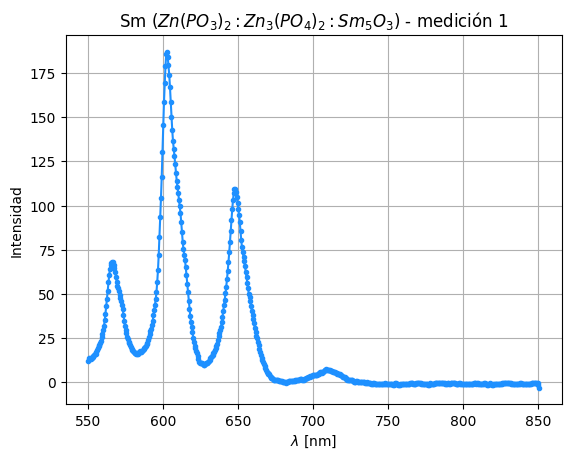

In [ ]:
plt.plot(sm_med_1_x,sm_med_1_y,'.-',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 1')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.grid()

**Calculamos cada pico**

In [ ]:
# Ubicamos el pico (1) más grande
sm_med_1_maxInt_1 = max(sm_med_1_y)
sm_med_1_pico_1 = sm_med_1_x[np.argmax(sm_med_1_y)]

print('Intensidad max 1 =',sm_med_1_maxInt_1)
print(r'Lambda max 1 =',sm_med_1_pico_1)

# Ubicamos los demás picos ajustando el rango a mano (viendo la gráfica)
# pico (2)
sm_med_1_maxInt_2 = max(sm_med_1_y[150:200])
sm_med_1_pico_2 = sm_med_1_x[150 + np.argmax(sm_med_1_y[150:200])]

print('Intensidad max 2 =',sm_med_1_maxInt_2)
print(r'Lambda max 2 =',sm_med_1_pico_2)

# pico (3)
sm_med_1_maxInt_3 = max(sm_med_1_y[0:50])
sm_med_1_pico_3 = sm_med_1_x[np.argmax(sm_med_1_y[0:50])]

print('Intensidad max 3 =',sm_med_1_maxInt_3)
print(r'Lambda max 3 =',sm_med_1_pico_3)

# pico (4)
sm_med_1_maxInt_4 = max(sm_med_1_y[300::])
sm_med_1_pico_4 = sm_med_1_x[300 + np.argmax(sm_med_1_y[300::])]

print('Intensidad max 4 =',sm_med_1_maxInt_4)
print(r'Lambda max 4 =',sm_med_1_pico_4)

Intensidad max 1 = 187.047696
Lambda max 1 = 602.5
Intensidad max 2 = 109.615393
Lambda max 2 = 648.0
Intensidad max 3 = 68.167659
Lambda max 3 = 566.0
Intensidad max 4 = 7.464719
Lambda max 4 = 708.5


**Hacemos otra gráfica localizando estos puntos máximos para confirmar**

(<matplotlib.lines.Line2D at 0x7b84c9996c10>,
 <matplotlib.lines.Line2D at 0x7b84c9996d50>)

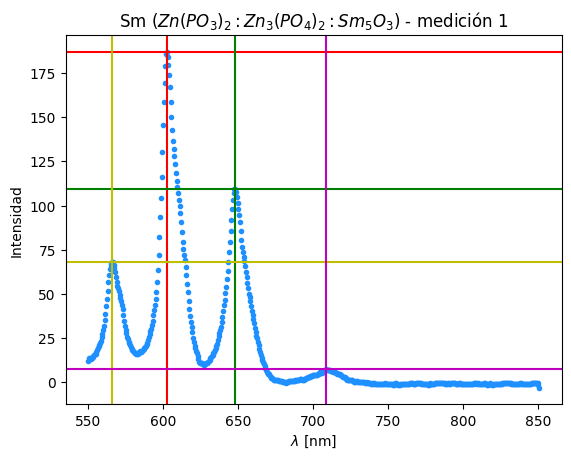

In [ ]:
plt.plot(sm_med_1_x,sm_med_1_y,'.',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 1')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.axvline(sm_med_1_pico_1,c='r'), plt.axhline(sm_med_1_maxInt_1,c='r') # pico (1)
plt.axvline(sm_med_1_pico_2,c='g'), plt.axhline(sm_med_1_maxInt_2,c='g') # pico (2)
plt.axvline(sm_med_1_pico_3,c='y'), plt.axhline(sm_med_1_maxInt_3,c='y') # pico (3)
plt.axvline(sm_med_1_pico_4,c='m'), plt.axhline(sm_med_1_maxInt_4,c='m') # pico (4)
#plt.grid()

**Hacemos otra gráfica con el "ancho de los puntos máximos" para calcular su incertidumbre**

In [ ]:
# Calculamos el ancho de cada pico

# ancho_pico(base_datos,mitad_intesidad)

# pico (1)
sm_med_1_tabla1, sm_med_1_pico_1_antes, sm_med_1_maxInt_1_antes, sm_med_1_pico_1_despues, sm_med_1_maxInt_1_despues = ancho_pico(sm_med_1[0:150],sm_med_1_maxInt_1/2)
# pico (2)
sm_med_1_tabla2, sm_med_1_pico_2_antes, sm_med_1_maxInt_2_antes, sm_med_1_pico_2_despues, sm_med_1_maxInt_2_despues = ancho_pico(sm_med_1[150::],sm_med_1_maxInt_2/2)
# pico (3)
sm_med_1_tabla3, sm_med_1_pico_3_antes, sm_med_1_maxInt_3_antes, sm_med_1_pico_3_despues, sm_med_1_maxInt_3_despues = ancho_pico(sm_med_1[0:49],sm_med_1_maxInt_3/2)
# pico (4)
sm_med_1_tabla4, sm_med_1_pico_4_antes, sm_med_1_maxInt_4_antes, sm_med_1_pico_4_despues, sm_med_1_maxInt_4_despues = ancho_pico(sm_med_1[250::],sm_med_1_maxInt_4/2)

(<matplotlib.lines.Line2D at 0x7b84c9904b90>,
 <matplotlib.lines.Line2D at 0x7b84c99051d0>)

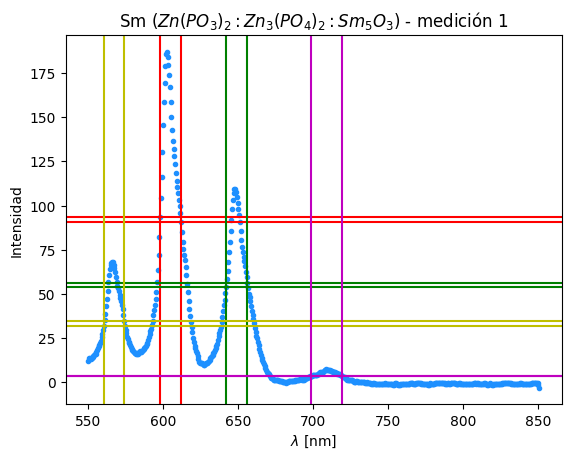

In [ ]:
plt.plot(sm_med_1_x,sm_med_1_y,'.',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 1')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')

# pico (1)
plt.axvline(sm_med_1_pico_1_antes,c='r'), plt.axhline(sm_med_1_maxInt_1_antes,c='r') #Antes
plt.axvline(sm_med_1_pico_1_despues,c='r'), plt.axhline(sm_med_1_maxInt_1_despues,c='r') #Después
# pico (2)
plt.axvline(sm_med_1_pico_2_antes,c='g'), plt.axhline(sm_med_1_maxInt_2_antes,c='g') #Antes
plt.axvline(sm_med_1_pico_2_despues,c='g'), plt.axhline(sm_med_1_maxInt_2_despues,c='g') #Después
# pico (3)
plt.axvline(sm_med_1_pico_3_antes,c='y'), plt.axhline(sm_med_1_maxInt_3_antes,c='y') #Antes
plt.axvline(sm_med_1_pico_3_despues,c='y'), plt.axhline(sm_med_1_maxInt_3_despues,c='y') #Después
# pico (4)
plt.axvline(sm_med_1_pico_4_antes,c='m'), plt.axhline(sm_med_1_maxInt_4_antes,c='m') #Antes
plt.axvline(sm_med_1_pico_4_despues,c='m'), plt.axhline(sm_med_1_maxInt_4_despues,c='m') #Después
#plt.grid()

In [ ]:
# Calculamos la incertidumbre para cada pico

# pico (1)
sm_med_1_pico_1_incer = abs(sm_med_1_pico_1_antes - sm_med_1_pico_1_despues)
print(r'Incertidumbre lambda max 1 =',sm_med_1_pico_1_incer)

# pico (2)
sm_med_1_pico_2_incer = abs(sm_med_1_pico_2_antes - sm_med_1_pico_2_despues)
print(r'Incertidumbre lambda max 2 =',sm_med_1_pico_2_incer)

# pico (3)
sm_med_1_pico_3_incer = abs(sm_med_1_pico_3_antes - sm_med_1_pico_3_despues)
print(r'Incertidumbre lambda max 3 =',sm_med_1_pico_3_incer)

# pico (4)
sm_med_1_pico_4_incer = abs(sm_med_1_pico_4_antes - sm_med_1_pico_4_despues)
print(r'Incertidumbre lambda max 4 =',sm_med_1_pico_4_incer)

Incertidumbre lambda max 1 = 14.0
Incertidumbre lambda max 2 = 14.0
Incertidumbre lambda max 3 = 13.5
Incertidumbre lambda max 4 = 20.5


**Ya verificados, recordamos cada punto máximo con su incertidumbre y calculamos la energía correspondiente**

In [ ]:
# energia(longitud_onda,incertidumbre_long_onda):
# pico (1)
print(r'Lambda max 1 =',sm_med_1_pico_1,'±',f"{sm_med_1_pico_1_incer:.2f}")
energia(sm_med_1_pico_1,sm_med_1_pico_1_incer)
# pico (2)
print(r'Lambda max 2 =',sm_med_1_pico_2,'±',f"{sm_med_1_pico_2_incer:.2f}")
energia(sm_med_1_pico_2,sm_med_1_pico_2_incer)
# pico (3)
print(r'Lambda max 3 =',sm_med_1_pico_3,'±',f"{sm_med_1_pico_3_incer:.2f}")
energia(sm_med_1_pico_3,sm_med_1_pico_3_incer)
# pico (4)
print(r'Lambda max 4 =',sm_med_1_pico_4,'±',f"{sm_med_1_pico_4_incer:.2f}")
energia(sm_med_1_pico_4,sm_med_1_pico_4_incer)

Lambda max 1 = 602.5 ± 14.00
Eergía correspondiente 16597.51 ± 771.75
Lambda max 2 = 648.0 ± 14.00
Eergía correspondiente 15432.10 ± 667.13
Lambda max 3 = 566.0 ± 13.50
Eergía correspondiente 17667.84 ± 843.29
Lambda max 4 = 708.5 ± 20.50
Eergía correspondiente 14114.33 ± 817.46


## **Medición 2** (espectrómetro Ocean Optics)

In [ ]:
# Leemos el archivo de datos
sm_med_2 = pd.read_csv(RUTA/"samario_395nm_medida1.csv",sep=',',skiprows=1,header=None,dtype='float')

# Le ponemos nombre a las columnas
sm_med_2.columns=(["x","y"])

# Imprimimos la tabla de datos
sm_med_2

,x,y
0,339.70,573.43
1,340.08,573.43
2,340.45,573.43
3,340.83,573.43
4,341.20,573.43
...,...,...
2043,1021.75,724.63
2044,1022.04,747.10
2045,1022.32,732.59
2046,1022.61,730.95


In [ ]:
# Guardamos las columnas en una lista cada una para poder graficarlas
sm_med_2_x = sm_med_2["x"].values
sm_med_2_y = sm_med_2["y"].values

# Las visualizamos
#print(sm_med_2_x)
#print(sm_med_2_y)

**Hacemos una gráfica inicial de los datos**

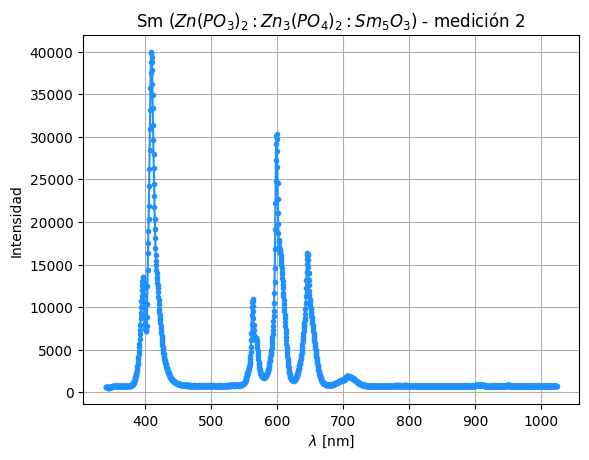

In [ ]:
plt.plot(sm_med_2_x,sm_med_2_y,'.-',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 2')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.grid()

**Calculamos cada pico**

In [ ]:
# Ubicamos el pico (1) más grande
sm_med_2_maxInt_1 = max(sm_med_2_y)
sm_med_2_pico_1 = sm_med_2_x[np.argmax(sm_med_2_y)]

print('Intensidad max 1 =',sm_med_2_maxInt_1)
print(r'Lambda max 1 =',sm_med_2_pico_1)

# Ubicamos los demás picos ajustando el rango a mano (viendo la gráfica)
# pico (2)
sm_med_2_maxInt_2 = max(sm_med_2_y[630:800])
sm_med_2_pico_2 = sm_med_2_x[630 + np.argmax(sm_med_2_y[630:800])]

print('Intensidad max 2 =',sm_med_2_maxInt_2)
print(r'Lambda max 2 =',sm_med_2_pico_2)

# pico (3)
sm_med_2_maxInt_3 = max(sm_med_2_y[850:1000])
sm_med_2_pico_3 = sm_med_2_x[850 + np.argmax(sm_med_2_y[850:1000])]

print('Intensidad max 3 =',sm_med_2_maxInt_3)
print(r'Lambda max 3 =',sm_med_2_pico_3)

# pico (4)
sm_med_2_maxInt_4 = max(sm_med_2_y[500:630])
sm_med_2_pico_4 = sm_med_2_x[500 + np.argmax(sm_med_2_y[500:630])]

print('Intensidad max 4 =',sm_med_2_maxInt_4)
print(r'Lambda max 4 =',sm_med_2_pico_4)

# pico (5)
sm_med_2_maxInt_5 = max(sm_med_2_y[1000::])
sm_med_2_pico_5 = sm_med_2_x[1000 + np.argmax(sm_med_2_y[1000::])]

print('Intensidad max 5 =',sm_med_2_maxInt_5)
print(r'Lambda max 5 =',sm_med_2_pico_5)

Intensidad max 1 = 39996.71
Lambda max 1 = 408.84
Intensidad max 2 = 30318.83
Lambda max 2 = 598.65
Intensidad max 3 = 16399.67
Lambda max 3 = 645.34
Intensidad max 4 = 10901.05
Lambda max 4 = 562.18
Intensidad max 5 = 1891.62
Lambda max 5 = 705.4


**Hacemos otra gráfica localizando estos puntos máximos para confirmar**

(<matplotlib.lines.Line2D at 0x7b84c99316d0>,
 <matplotlib.lines.Line2D at 0x7b84c9931590>)

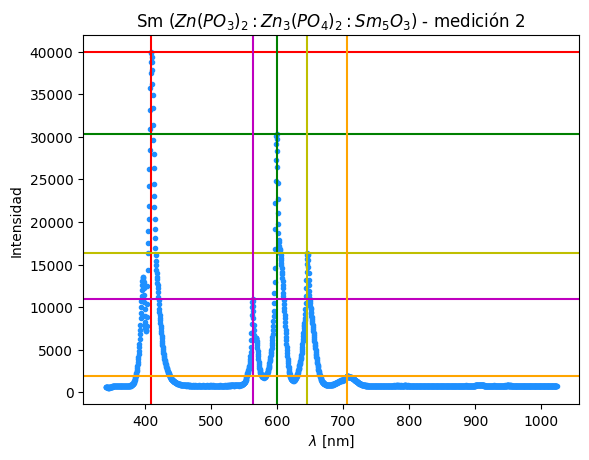

In [ ]:
plt.plot(sm_med_2_x,sm_med_2_y,'.',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 2')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.axvline(sm_med_2_pico_1,c='r'), plt.axhline(sm_med_2_maxInt_1,c='r') # pico (1)
plt.axvline(sm_med_2_pico_2,c='g'), plt.axhline(sm_med_2_maxInt_2,c='g') # pico (2)
plt.axvline(sm_med_2_pico_3,c='y'), plt.axhline(sm_med_2_maxInt_3,c='y') # pico (3)
plt.axvline(sm_med_2_pico_4,c='m'), plt.axhline(sm_med_2_maxInt_4,c='m') # pico (4)
plt.axvline(sm_med_2_pico_5,c='orange'), plt.axhline(sm_med_2_maxInt_5,c='orange') # pico (5)
#plt.grid()

**Hacemos otra gráfica con el "ancho de los puntos máximos" para calcular su incertidumbre**

In [ ]:
# Calculamos el ancho de cada pico

# ancho_pico(base_datos,mitad_intesidad)

# pico (1)
sm_med_2_tabla1, sm_med_2_pico_1_antes, sm_med_2_maxInt_1_antes, sm_med_2_pico_1_despues, sm_med_2_maxInt_1_despues = ancho_pico(sm_med_2[0:500],sm_med_2_maxInt_1/2)
# pico (2)
sm_med_2_tabla2, sm_med_2_pico_2_antes, sm_med_2_maxInt_2_antes, sm_med_2_pico_2_despues, sm_med_2_maxInt_2_despues = ancho_pico(sm_med_2[650:710],sm_med_2_maxInt_2/2)
# pico (3)
sm_med_2_tabla3, sm_med_2_pico_3_antes, sm_med_2_maxInt_3_antes, sm_med_2_pico_3_despues, sm_med_2_maxInt_3_despues = ancho_pico(sm_med_2[747::],sm_med_2_maxInt_3*(2/3))
# pico (4)
sm_med_2_tabla4, sm_med_2_pico_4_antes, sm_med_2_maxInt_4_antes, sm_med_2_pico_4_despues, sm_med_2_maxInt_4_despues = ancho_pico(sm_med_2[250:650],sm_med_2_maxInt_4/2)
# pico (5)
sm_med_2_tabla5, sm_med_2_pico_5_antes, sm_med_2_maxInt_5_antes, sm_med_2_pico_5_despues, sm_med_2_maxInt_5_despues = ancho_pico(sm_med_2[950::],sm_med_2_maxInt_5*(1/2))

(<matplotlib.lines.Line2D at 0x7b84c3737890>,
 <matplotlib.lines.Line2D at 0x7b84c3737390>)

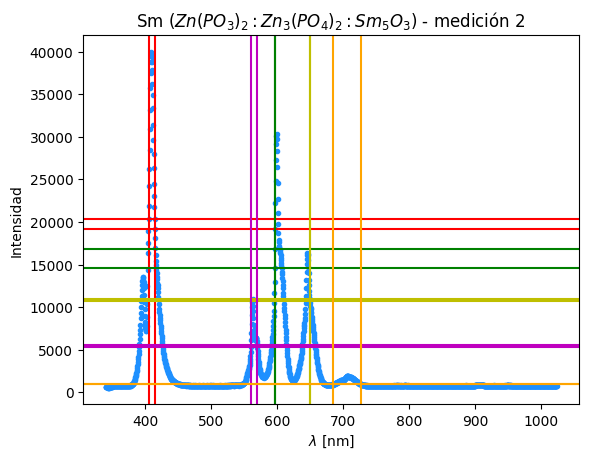

In [ ]:
plt.plot(sm_med_2_x,sm_med_2_y,'.',c='dodgerblue')
plt.title('Sm ($Zn(PO_3)_2:Zn_3(PO_4)_2:Sm_5O_3$) - medición 2')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')

# pico (1)
plt.axvline(sm_med_2_pico_1_antes,c='r'), plt.axhline(sm_med_2_maxInt_1_antes,c='r') #Antes
plt.axvline(sm_med_2_pico_1_despues,c='r'), plt.axhline(sm_med_2_maxInt_1_despues,c='r') #Después
# pico (2)
plt.axvline(sm_med_2_pico_2_antes,c='g'), plt.axhline(sm_med_2_maxInt_2_antes,c='g') #Antes
plt.axvline(sm_med_2_pico_2_despues,c='g'), plt.axhline(sm_med_2_maxInt_2_despues,c='g') #Después
# pico (3)
plt.axvline(sm_med_2_pico_3_antes,c='y'), plt.axhline(sm_med_2_maxInt_3_antes,c='y') #Antes
plt.axvline(sm_med_2_pico_3_despues,c='y'), plt.axhline(sm_med_2_maxInt_3_despues,c='y') #Después
# pico (4)
plt.axvline(sm_med_2_pico_4_antes,c='m'), plt.axhline(sm_med_2_maxInt_4_antes,c='m') #Antes
plt.axvline(sm_med_2_pico_4_despues,c='m'), plt.axhline(sm_med_2_maxInt_4_despues,c='m') #Después
# pico (5)
plt.axvline(sm_med_2_pico_5_antes,c='orange'), plt.axhline(sm_med_2_maxInt_5_antes,c='orange') #Antes
plt.axvline(sm_med_2_pico_5_despues,c='orange'), plt.axhline(sm_med_2_maxInt_5_despues,c='orange') #Después
#plt.grid()

In [ ]:
# Calculamos la incertidumbre para cada pico

# pico (1)
sm_med_2_pico_1_incer = abs(sm_med_2_pico_1_antes - sm_med_2_pico_1_despues)
print(r'Incertidumbre lambda max 1 =',sm_med_2_pico_1_incer)

# pico (2)
sm_med_2_pico_2_incer = abs(sm_med_2_pico_2_antes - sm_med_2_pico_2_despues)
print(r'Incertidumbre lambda max 2 =',sm_med_2_pico_2_incer)

# pico (3)
sm_med_2_pico_3_incer = abs(sm_med_2_pico_3_antes - sm_med_2_pico_3_despues)
print(r'Incertidumbre lambda max 3 =',sm_med_2_pico_3_incer)

# pico (4)
sm_med_2_pico_4_incer = abs(sm_med_2_pico_4_antes - sm_med_2_pico_4_despues)
print(r'Incertidumbre lambda max 4 =',sm_med_2_pico_4_incer)

# pico (5)
sm_med_2_pico_5_incer = abs(sm_med_2_pico_5_antes - sm_med_2_pico_5_despues)
print(r'Incertidumbre lambda max 5 =',sm_med_2_pico_5_incer)

Incertidumbre lambda max 1 = 9.580000000000041
Incertidumbre lambda max 2 = 0.35000000000002274
Incertidumbre lambda max 3 = 0.34000000000003183
Incertidumbre lambda max 4 = 9.519999999999982
Incertidumbre lambda max 5 = 41.26999999999998


**Ya verificados, recordamos cada punto máximo con su incertidumbre y calculamos la energía correspondiente**

In [ ]:
# energia(longitud_onda,incertidumbre_long_onda):
# pico (1)
print(r'Lambda max 1 =',sm_med_2_pico_1,'±',f"{sm_med_2_pico_1_incer:.2f}")
energia(sm_med_2_pico_1,sm_med_2_pico_1_incer)
# pico (2)
print(r'Lambda max 2 =',sm_med_2_pico_2,'±',f"{sm_med_2_pico_2_incer:.2f}")
energia(sm_med_2_pico_2,sm_med_2_pico_2_incer)
# pico (3)
print(r'Lambda max 3 =',sm_med_2_pico_3,'±',f"{sm_med_2_pico_3_incer:.2f}")
energia(sm_med_2_pico_3,sm_med_2_pico_3_incer)
# pico (4)
print(r'Lambda max 4 =',sm_med_2_pico_4,'±',f"{sm_med_2_pico_4_incer:.2f}")
energia(sm_med_2_pico_4,sm_med_2_pico_4_incer)
# pico (5)
print(r'Lambda max 5 =',sm_med_2_pico_5,'±',f"{sm_med_2_pico_5_incer:.2f}")
energia(sm_med_2_pico_5,sm_med_2_pico_5_incer)

Lambda max 1 = 408.84 ± 9.58
Eergía correspondiente 24459.45 ± 1146.90
Lambda max 2 = 598.65 ± 0.35
Eergía correspondiente 16704.25 ± 19.53
Lambda max 3 = 645.34 ± 0.34
Eergía correspondiente 15495.71 ± 16.33
Lambda max 4 = 562.18 ± 9.52
Eergía correspondiente 17787.90 ± 602.62
Lambda max 5 = 705.4 ± 41.27
Eergía correspondiente 14176.35 ± 1664.50


<hr style="border: 5px solid #000;">

# Tb - Tetraborato de litio con terbio

$Li_2B_4O_7:Tb_4O_7$

*(98%) (2%)*

**Notación**:

tb: terbio \
med: medición

## **Medición 1** (es el único que hicimos) (espectrómetro PerkinElmer)

In [ ]:
# Leemos el archivo de datos
tb_med_1 = pd.read_csv(RUTA/"EuVLx#21.sp",sep='\t',skiprows=54,header=None,dtype='float')

# Le ponemos nombre a las columnas
tb_med_1.columns=(["x","y"])

# Imprimimos la tabla de datos
tb_med_1

,x,y
0,450.0,29.595000
1,450.5,29.895257
2,451.0,29.548583
3,451.5,29.047712
4,452.0,29.207287
...,...,...
671,785.5,-2.075098
672,786.0,-2.000598
673,786.5,-2.003469
674,787.0,-2.012113


In [ ]:
# Guardamos las columnas en una lista cada una para poder graficarlas
tb_med_1_x = tb_med_1["x"].values
tb_med_1_y = tb_med_1["y"].values

# Las visualizamos
#print(tb_med_1_x)
#print(tb_med_1_y)

**Hacemos una gráfica inicial de los datos**

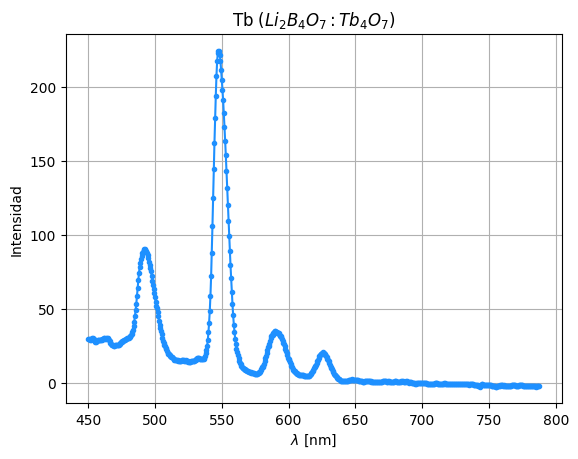

In [ ]:
plt.plot(tb_med_1_x,tb_med_1_y,'.-',c='dodgerblue')
plt.title('Tb ($Li_2B_4O_7:Tb_4O_7$)')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.grid()

**Calculamos cada pico**

In [ ]:
# Ubicamos el pico (1) más grande
tb_med_1_maxInt_1 = max(tb_med_1_y)
tb_med_1_pico_1 = tb_med_1_x[np.argmax(tb_med_1_y)]

print('Intensidad max 1 =',tb_med_1_maxInt_1)
print(r'Lambda max 1 =',tb_med_1_pico_1)

# Ubicamos los demás picos ajustando el rango a mano (viendo la gráfica)
# pico (2)
tb_med_1_maxInt_2 = max(tb_med_1_y[0:100])
tb_med_1_pico_2 = tb_med_1_x[np.argmax(tb_med_1_y[0:100])]

print('Intensidad max 2 =',tb_med_1_maxInt_2)
print(r'Lambda max 2 =',tb_med_1_pico_2)

# pico (3)
tb_med_1_maxInt_3 = max(tb_med_1_y[250:300])
tb_med_1_pico_3 = tb_med_1_x[250 + np.argmax(tb_med_1_y[250:300])]

print('Intensidad max 3 =',tb_med_1_maxInt_3)
print(r'Lambda max 3 =',tb_med_1_pico_3)

# pico (4)
tb_med_1_maxInt_4 = max(tb_med_1_y[350::])
tb_med_1_pico_4 = tb_med_1_x[350 + np.argmax(tb_med_1_y[350::])]

print('Intensidad max 4 =',tb_med_1_maxInt_4)
print(r'Lambda max 4 =',tb_med_1_pico_4)

Intensidad max 1 = 224.658106
Lambda max 1 = 547.5
Intensidad max 2 = 90.558636
Lambda max 2 = 492.0
Intensidad max 3 = 35.224833
Lambda max 3 = 590.0
Intensidad max 4 = 20.776606
Lambda max 4 = 625.5


**Hacemos otra gráfica localizando estos puntos máximos para confirmar**

(<matplotlib.lines.Line2D at 0x7b84c9a7e0d0>,
 <matplotlib.lines.Line2D at 0x7b84c9a7e210>)

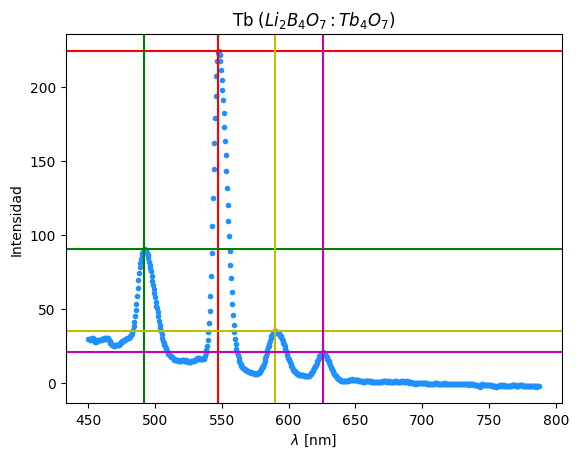

In [ ]:
plt.plot(tb_med_1_x,tb_med_1_y,'.',c='dodgerblue')
plt.title('Tb ($Li_2B_4O_7:Tb_4O_7$)')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.axvline(tb_med_1_pico_1,c='r'), plt.axhline(tb_med_1_maxInt_1,c='r') # pico (1)
plt.axvline(tb_med_1_pico_2,c='g'), plt.axhline(tb_med_1_maxInt_2,c='g') # pico (2)
plt.axvline(tb_med_1_pico_3,c='y'), plt.axhline(tb_med_1_maxInt_3,c='y') # pico (3)
plt.axvline(tb_med_1_pico_4,c='m'), plt.axhline(tb_med_1_maxInt_4,c='m') # pico (4)
#plt.grid()

**Hacemos otra gráfica con el "ancho de los puntos máximos" para calcular su incertidumbre**

In [ ]:
# Calculamos el ancho de cada pico

# ancho_pico(base_datos,mitad_intesidad)

# pico (1)
tb_med_1_tabla1, tb_med_1_pico_1_antes, tb_med_1_maxInt_1_antes, tb_med_1_pico_1_despues, tb_med_1_maxInt_1_despues = ancho_pico(tb_med_1[0:210],tb_med_1_maxInt_1/2)
# pico (2)
tb_med_1_tabla2, tb_med_1_pico_2_antes, tb_med_1_maxInt_2_antes, tb_med_1_pico_2_despues, tb_med_1_maxInt_2_despues = ancho_pico(tb_med_1[0:110],tb_med_1_maxInt_2/2)
# pico (3)
tb_med_1_tabla3, tb_med_1_pico_3_antes, tb_med_1_maxInt_3_antes, tb_med_1_pico_3_despues, tb_med_1_maxInt_3_despues = ancho_pico(tb_med_1[250:300],tb_med_1_maxInt_3/2)
# pico (4)
tb_med_1_tabla4, tb_med_1_pico_4_antes, tb_med_1_maxInt_4_antes, tb_med_1_pico_4_despues, tb_med_1_maxInt_4_despues = ancho_pico(tb_med_1[310:500],tb_med_1_maxInt_4/2)

(<matplotlib.lines.Line2D at 0x7b84ca789e50>,
 <matplotlib.lines.Line2D at 0x7b84ca789f90>)

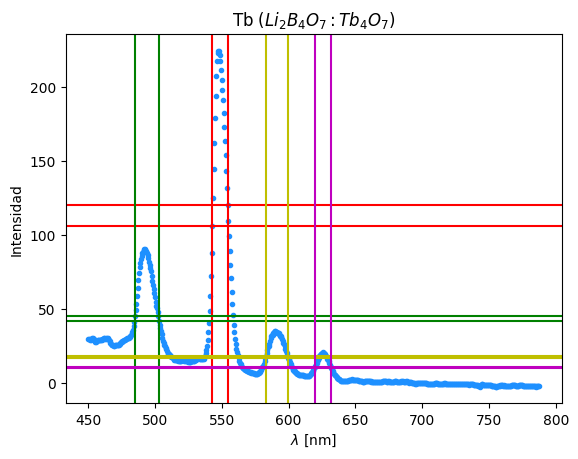

In [ ]:
plt.plot(tb_med_1_x,tb_med_1_y,'.',c='dodgerblue')
plt.title('Tb ($Li_2B_4O_7:Tb_4O_7$)')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')

# pico (1)
plt.axvline(tb_med_1_pico_1_antes,c='r'), plt.axhline(tb_med_1_maxInt_1_antes,c='r') #Antes
plt.axvline(tb_med_1_pico_1_despues,c='r'), plt.axhline(tb_med_1_maxInt_1_despues,c='r') #Después
# pico (2)
plt.axvline(tb_med_1_pico_2_antes,c='g'), plt.axhline(tb_med_1_maxInt_2_antes,c='g') #Antes
plt.axvline(tb_med_1_pico_2_despues,c='g'), plt.axhline(tb_med_1_maxInt_2_despues,c='g') #Después
# pico (3)
plt.axvline(tb_med_1_pico_3_antes,c='y'), plt.axhline(tb_med_1_maxInt_3_antes,c='y') #Antes
plt.axvline(tb_med_1_pico_3_despues,c='y'), plt.axhline(tb_med_1_maxInt_3_despues,c='y') #Después
# pico (4)
plt.axvline(tb_med_1_pico_4_antes,c='m'), plt.axhline(tb_med_1_maxInt_4_antes,c='m') #Antes
plt.axvline(tb_med_1_pico_4_despues,c='m'), plt.axhline(tb_med_1_maxInt_4_despues,c='m') #Después
#plt.grid()

In [ ]:
# Calculamos la incertidumbre para cada pico

# pico (1)
tb_med_1_pico_1_incer = abs(tb_med_1_pico_1_antes - tb_med_1_pico_1_despues)
print(r'Incertidumbre lambda max 1 =',tb_med_1_pico_1_incer)

# pico (2)
tb_med_1_pico_2_incer = abs(tb_med_1_pico_2_antes - tb_med_1_pico_2_despues)
print(r'Incertidumbre lambda max 2 =',tb_med_1_pico_2_incer)

# pico (3)
tb_med_1_pico_3_incer = abs(tb_med_1_pico_3_antes - tb_med_1_pico_3_despues)
print(r'Incertidumbre lambda max 3 =',tb_med_1_pico_3_incer)

# pico (4)
tb_med_1_pico_4_incer = abs(tb_med_1_pico_4_antes - tb_med_1_pico_4_despues)
print(r'Incertidumbre lambda max 4 =',tb_med_1_pico_4_incer)

Incertidumbre lambda max 1 = 11.5
Incertidumbre lambda max 2 = 18.0
Incertidumbre lambda max 3 = 16.5
Incertidumbre lambda max 4 = 12.5


**Ya verificados, recordamos cada punto máximo con su incertidumbre y calculamos la energía correspondiente**

In [ ]:
# energia(longitud_onda,incertidumbre_long_onda):
# pico (1)
print(r'Lambda max 1 =',tb_med_1_pico_1,'±',f"{tb_med_1_pico_1_incer:.2f}")
energia(tb_med_1_pico_1,tb_med_1_pico_1_incer)
# pico (2)
print(r'Lambda max 2 =',tb_med_1_pico_2,'±',f"{tb_med_1_pico_2_incer:.2f}")
energia(tb_med_1_pico_2,tb_med_1_pico_2_incer)
# pico (3)
print(r'Lambda max 3 =',tb_med_1_pico_3,'±',f"{tb_med_1_pico_3_incer:.2f}")
energia(tb_med_1_pico_3,tb_med_1_pico_3_incer)
# pico (4)
print(r'Lambda max 4 =',tb_med_1_pico_4,'±',f"{tb_med_1_pico_4_incer:.2f}")
energia(tb_med_1_pico_4,tb_med_1_pico_4_incer)

Lambda max 1 = 547.5 ± 11.50
Eergía correspondiente 18264.84 ± 767.63
Lambda max 2 = 492.0 ± 18.00
Eergía correspondiente 20325.20 ± 1489.20
Lambda max 3 = 590.0 ± 16.50
Eergía correspondiente 16949.15 ± 948.75
Lambda max 4 = 625.5 ± 12.50
Eergía correspondiente 15987.21 ± 639.23


Calculamos las posibles transiciones:

In [ ]:
# buscar_transiciones(E_obs,ion,niveles,E_menos=None,E_mas=None,Emax=40000)

display(buscar_transiciones(18264.84,"Tb3+",niveles,18264.84-767.63,18264.84+767.63))

,estado_i,Ei_cm-1,estado_f,Ef_cm-1,DeltaE_cm-1,lambda_calc_nm,residuo_cm-1,error_abs_cm-1
0,5K_9,39176.180627,5D_4,20919.297733,18256.882893,547.738629,-7.957107,7.957107
1,5D_4,20919.297733,7F_5,2040.021380,18879.276353,529.681319,614.436353,614.436353
2,5D_4,20919.297733,7F_4,3320.580126,17598.717608,568.223221,-666.122392,666.122392
3,5D_2,39933.305965,5D_4,20919.297733,19014.008231,525.928036,749.168231,749.168231


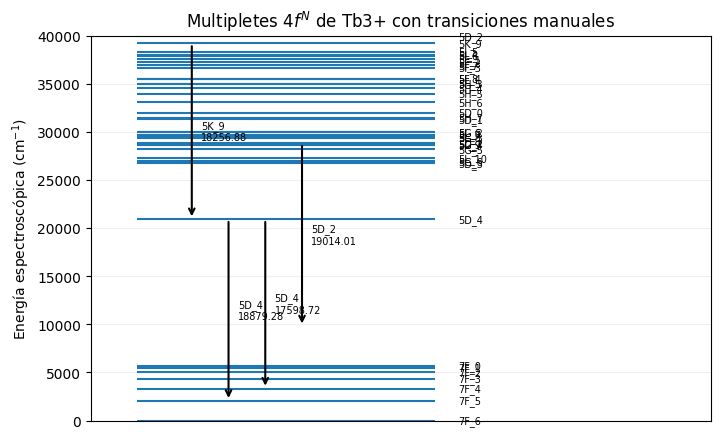

In [ ]:
transiciones_tb = [
    {"estado_i": "5K_9", "E_obs": 18256.882893},
    {"estado_i": "5D_4", "E_obs": 18879.276353},
    {"estado_i": "5D_4", "E_obs": 17598.717608},
    {"estado_i": "5D_2", "E_obs": 19014.008231} ]

diagrama_dieke_transiciones(niveles,"Tb3+",transiciones_tb,Emax=40000)

Descartamos el 3 porque no tiene mucho sentido, no cae a ningún nivel.

Nos quedamos con el 1 simplemente porque se ve más claro.

In [ ]:
# buscar_transiciones(E_obs,ion,niveles,E_menos=None,E_mas=None,Emax=40000)

display(buscar_transiciones(20325.20,"Tb3+",niveles,20325.20-1489.20,20325.20+1489.20))

,estado_i,Ei_cm-1,estado_f,Ef_cm-1,DeltaE_cm-1,lambda_calc_nm,residuo_cm-1,error_abs_cm-1
0,5D_4,20919.297733,7F_6,0.000000,20919.297733,478.027519,594.097733,594.097733
1,5D_3,26715.762893,7F_0,5705.030071,21010.732822,475.947226,685.532822,685.532822
2,5G_6,26915.319682,7F_0,5705.030071,21210.289611,471.469281,885.089611,885.089611
3,5D_3,26715.762893,7F_1,5477.001017,21238.761876,470.837239,913.561876,913.561876
4,5G_6,26915.319682,7F_1,5477.001017,21438.318665,466.454490,1113.118665,1113.118665
5,5L_10,27250.951649,7F_0,5705.030071,21545.921578,464.124960,1220.721578,1220.721578
6,5D_2,39933.305965,5D_4,20919.297733,19014.008231,525.928036,-1311.191769,1311.191769
7,5D_3,26715.762893,7F_2,5012.991933,21702.770960,460.770655,1377.570960,1377.570960
8,5D_4,20919.297733,7F_5,2040.021380,18879.276353,529.681319,-1445.923647,1445.923647
9,5L_10,27250.951649,7F_1,5477.001017,21773.950632,459.264383,1448.750632,1448.750632


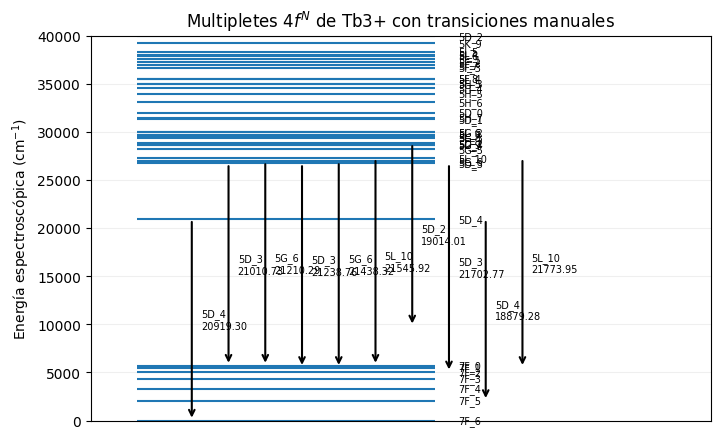

In [ ]:
transiciones_tb = [
    {"estado_i": "5D_4", "E_obs": 20919.297733},
    {"estado_i": "5D_3", "E_obs": 21010.732822},
    {"estado_i": "5G_6", "E_obs": 21210.289611},
    {"estado_i": "5D_3", "E_obs": 21238.761876},
    {"estado_i": "5G_6", "E_obs": 21438.318665},
    {"estado_i": "5L_10", "E_obs": 21545.921578},
    {"estado_i": "5D_2", "E_obs": 19014.008231},
    {"estado_i": "5D_3", "E_obs": 21702.770960},
    {"estado_i": "5D_4", "E_obs": 18879.276353},
    {"estado_i": "5L_10", "E_obs": 21773.950632} ]

diagrama_dieke_transiciones(niveles,"Tb3+",transiciones_tb,Emax=40000)

Del 1 al 5 y el 7 se ven muy similares, así que descartamos todas las demás.

Me quedo con el 3 porque es casi el de enmedio de estos candidatos.

In [ ]:
# buscar_transiciones(E_obs,ion,niveles,E_menos=None,E_mas=None,Emax=40000)

display(buscar_transiciones(16949.15,"Tb3+",niveles,16949.15-948.75,16949.15+948.75))

,estado_i,Ei_cm-1,estado_f,Ef_cm-1,DeltaE_cm-1,lambda_calc_nm,residuo_cm-1,error_abs_cm-1
0,5I_6,37905.441886,5D_4,20919.297733,16986.144153,588.715126,36.994153,36.994153
1,5I_4,37997.451922,5D_4,20919.297733,17078.154189,585.543373,129.004189,129.004189
2,5F_1,37531.370189,5D_4,20919.297733,16612.072456,601.971851,-337.077544,337.077544
3,5D_4,20919.297733,7F_3,4311.845662,16607.452071,602.139326,-341.697929,341.697929
4,5I_5,38319.540891,5D_4,20919.297733,17400.243158,574.704612,451.093158,451.093158
5,5F_2,37220.961821,5D_4,20919.297733,16301.664087,613.434306,-647.485913,647.485913
6,5D_4,20919.297733,7F_4,3320.580126,17598.717608,568.223221,649.567608,649.567608


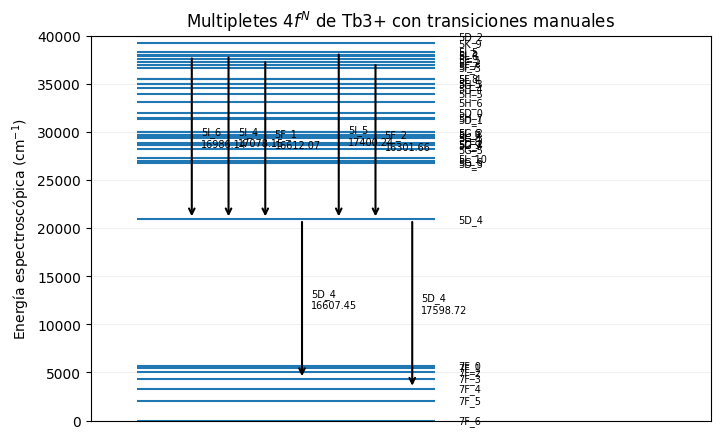

In [ ]:
transiciones_tb = [
    {"estado_i": "5I_6", "E_obs": 16986.144153},
    {"estado_i": "5I_4", "E_obs": 17078.154189},
    {"estado_i": "5F_1", "E_obs": 16612.072456},
    {"estado_i": "5D_4", "E_obs": 16607.452071},
    {"estado_i": "5I_5", "E_obs": 17400.243158},
    {"estado_i": "5F_2", "E_obs": 16301.664087},
    {"estado_i": "5D_4", "E_obs": 17598.717608} ]

diagrama_dieke_transiciones(niveles,"Tb3+",transiciones_tb,Emax=40000)

Quito el 3 y el 6 porque no siguen la tendencia de los demás.

Me quedo con el 2 por estar enmedio de estos candidatos.

In [ ]:
# buscar_transiciones(E_obs,ion,niveles,E_menos=None,E_mas=None,Emax=40000)

display(buscar_transiciones(15987.21,"Tb3+",niveles,15987.21-639.23,15987.21+639.23))

,estado_i,Ei_cm-1,estado_f,Ef_cm-1,DeltaE_cm-1,lambda_calc_nm,residuo_cm-1,error_abs_cm-1
0,5I_7,36905.977853,5D_4,20919.297733,15986.680119,625.520741,-0.529881,0.529881
1,5D_4,20919.297733,7F_2,5012.991933,15906.305800,628.681488,-80.904200,80.904200
2,5F_3,36648.247041,5D_4,20919.297733,15728.949308,635.770375,-258.260692,258.260692
3,5F_2,37220.961821,5D_4,20919.297733,16301.664087,613.434306,314.454087,314.454087
4,5D_4,20919.297733,7F_1,5477.001017,15442.296716,647.572067,-544.913284,544.913284
5,5D_4,20919.297733,7F_3,4311.845662,16607.452071,602.139326,620.242071,620.242071
6,5F_1,37531.370189,5D_4,20919.297733,16612.072456,601.971851,624.862456,624.862456


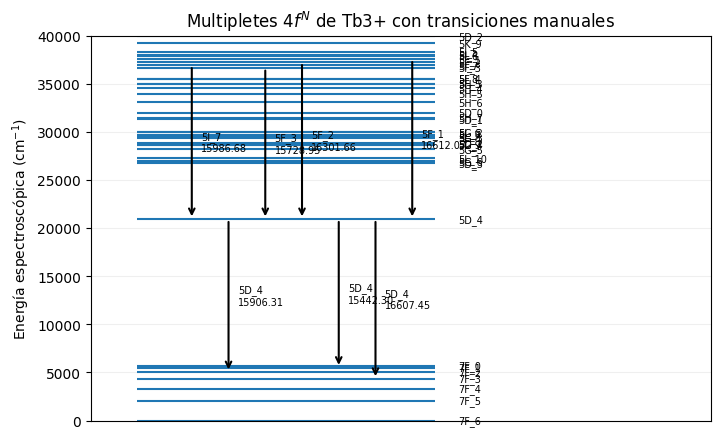

In [ ]:
transiciones_tb = [
    {"estado_i": "5I_7", "E_obs": 15986.680119},
    {"estado_i": "5D_4", "E_obs": 15906.305800},
    {"estado_i": "5F_3", "E_obs": 15728.949308},
    {"estado_i": "5F_2", "E_obs": 16301.664087},
    {"estado_i": "5D_4", "E_obs": 15442.296716},
    {"estado_i": "5D_4", "E_obs": 16607.452071},
    {"estado_i": "5F_1", "E_obs": 16612.072456} ]

diagrama_dieke_transiciones(niveles,"Tb3+",transiciones_tb,Emax=40000)

Nos quedamos con los de arriba por ser mayoría.

Me quedo con el 3 por estar en medio.

**Gráficas buenas para el reporte y la presentación**

Este es el prototipo de lo que me interesa reportar, ahorita la tuneamos

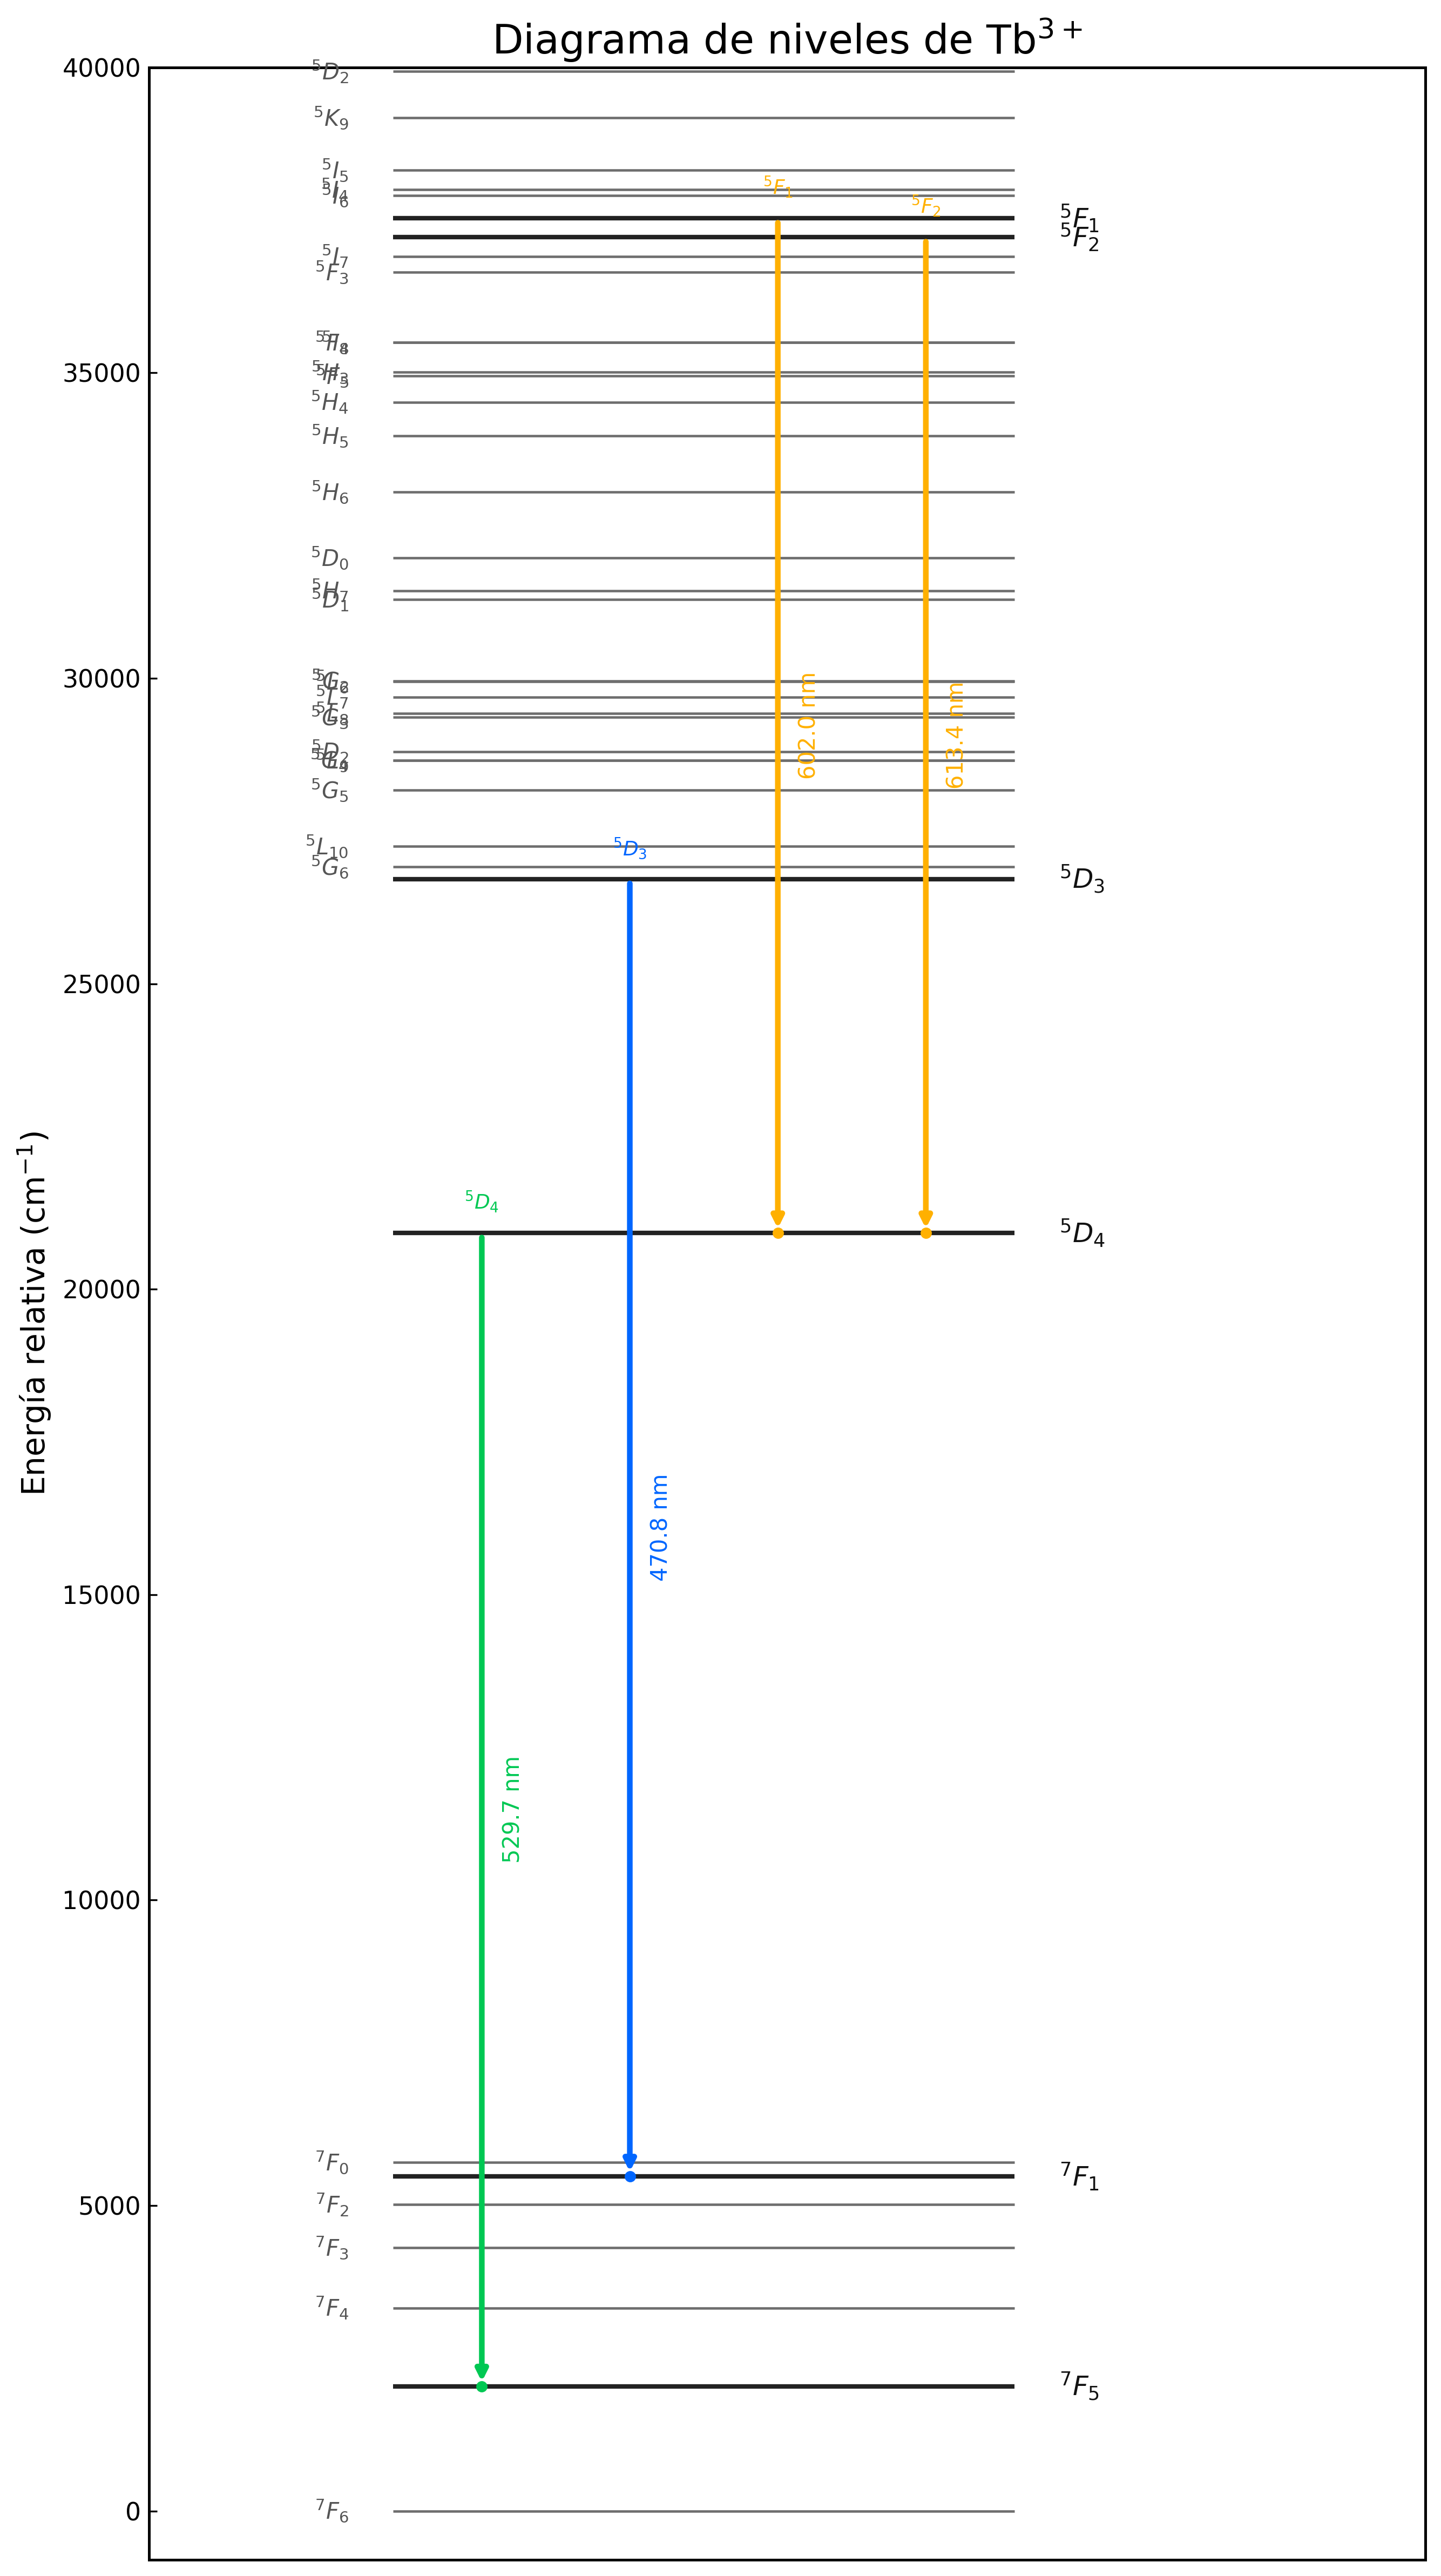

In [251]:
transiciones_tb = [
    {"estado_i": "5D_4", "E_obs": 18879.276353},
    {"estado_i": "5D_3", "E_obs": 21238.761876},
    {"estado_i": "5F_1", "E_obs": 16612.072456},
    {"estado_i": "5F_2", "E_obs": 16301.664087} ]

diagrama_dieke_transiciones(niveles,"Tb3+",transiciones_tb,Emax=40000)

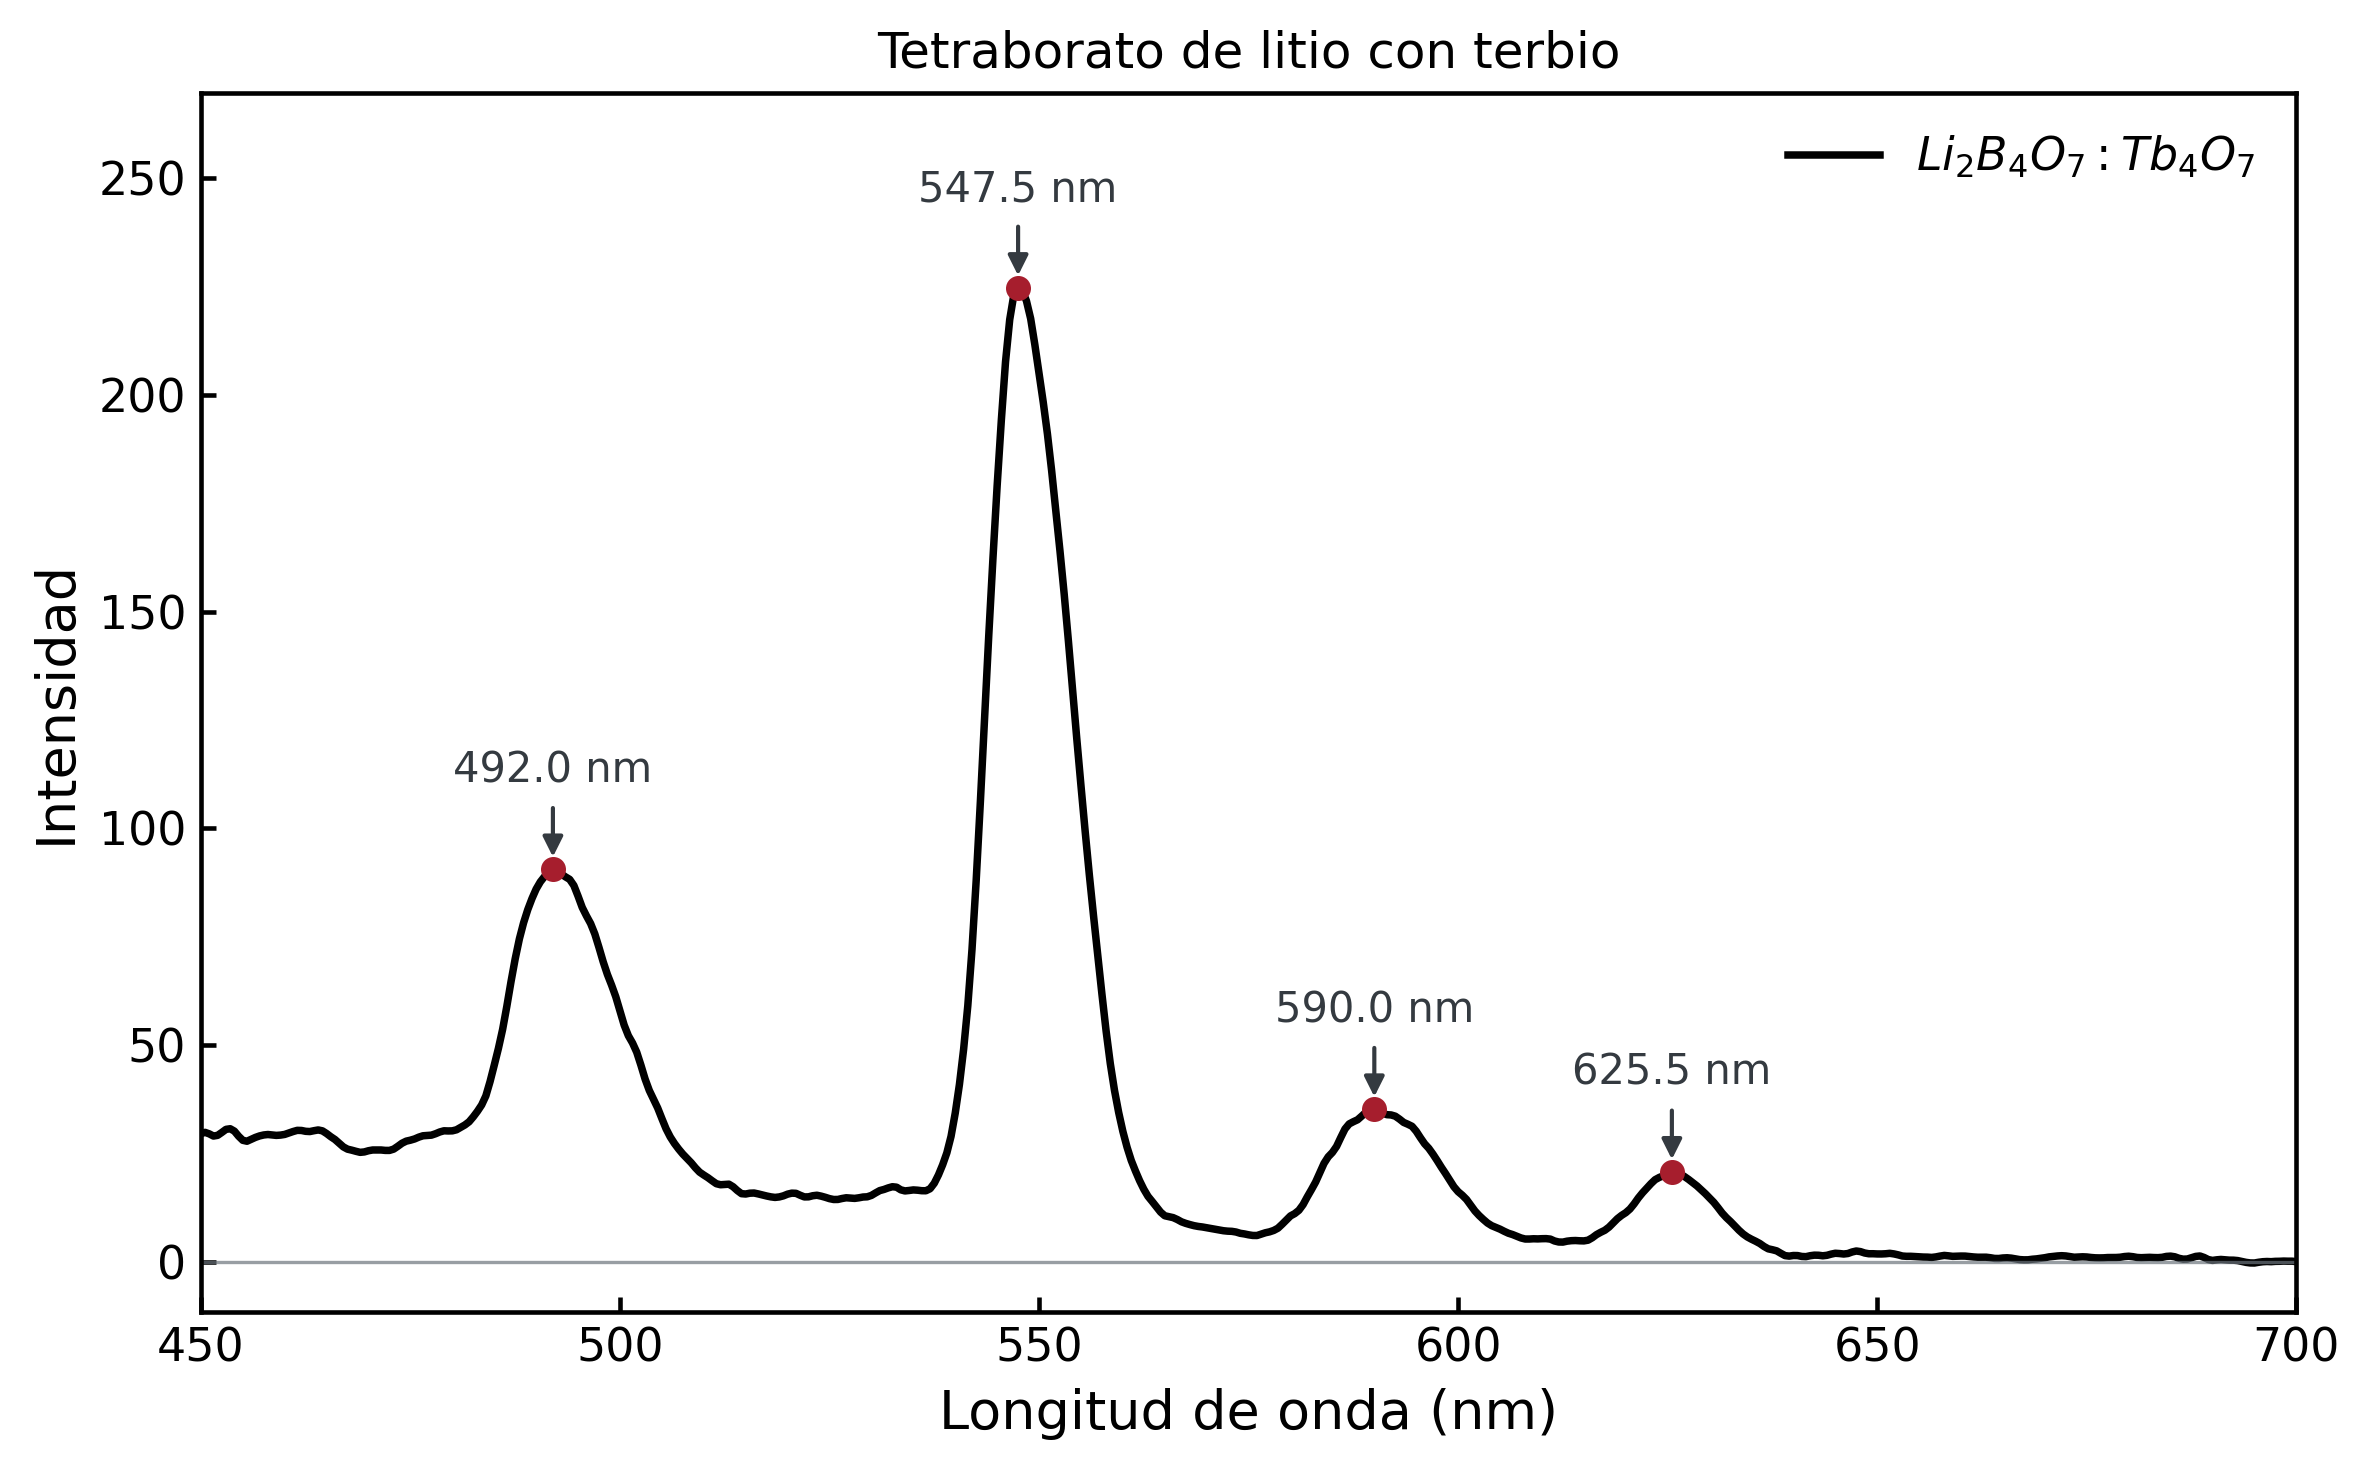

In [279]:
fig, ax = plt.subplots(figsize=(8,5),dpi=300)

# Límites del eje x
x_min = 450
x_max = 700

# Seleccionamos únicamente los datos dentro del rango mostrado
mascara = (tb_med_1_x >= x_min) & (tb_med_1_x <= x_max)
y_visible = tb_med_1_y[mascara]

# Calculamos el rango de intensidades visible
y_min = min(y_visible)
y_max = max(y_visible)
rango_y = y_max - y_min

# Curva principal
ax.plot(
    tb_med_1_x,tb_med_1_y,
    color="black",
    linewidth=1.8,
    label=r"$Li_2B_4O_7:Tb_4O_7$"
)

# Línea base
ax.axhline(0,color="#6C757D",linewidth=0.8,alpha=0.7)

# Guardamos los picos y sus intensidades
tb_med_1_picos = [
    tb_med_1_pico_1,
    tb_med_1_pico_2,
    tb_med_1_pico_3,
    tb_med_1_pico_4 ]

tb_med_1_intensidades = [
    tb_med_1_maxInt_1,
    tb_med_1_maxInt_2,
    tb_med_1_maxInt_3,
    tb_med_1_maxInt_4 ]

# Marcadores y etiquetas de los picos
for pico, intensidad in zip(tb_med_1_picos,tb_med_1_intensidades):

    # Solo mostramos los picos que están dentro del rango en x
    if x_min <= pico <= x_max:

        # Punto del pico
        ax.plot(
            pico,intensidad,
            marker="o",
            markersize=5,
            color="#A61E2D",
            zorder=3
        )

        # Flecha y longitud de onda
        ax.annotate(
            fr"{pico:.1f} nm",
            xy=(pico,intensidad),
            xytext=(pico,intensidad + 0.08*rango_y),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#343A40",
            arrowprops=dict(
                arrowstyle="-|>",
                color="#343A40",
                lw=1.0,
                shrinkA=2,
                shrinkB=3
            )
        )

ax.set_xlabel(r"Longitud de onda (nm)",fontsize=13)
ax.set_ylabel("Intensidad",fontsize=13)
ax.set_title(r"Tetraborato de litio con terbio")
ax.legend(frameon=False,loc="upper right",fontsize=11)
ax.tick_params(direction="in",labelsize=11,width=1.1)

for borde in ax.spines.values():
    borde.set_linewidth(1.1)

# Ajustamos el rango mostrado en el eje x
ax.set_xlim(x_min,x_max)

# Añadimos espacio suficiente arriba para que no se corten los picos ni sus etiquetas
ax.set_ylim(
    bottom=y_min - 0.05*rango_y,
    top=y_max + 0.20*rango_y
)

plt.tight_layout()
plt.show()

In [ ]:
# Leemos el archivo de datos
pr_med_4 = pd.read_csv(RUTA/"plaseodimio_medida_parte3.csv",sep=',',skiprows=1,header=None,dtype='float')

# Le ponemos nombre a las columnas
pr_med_4.columns=(["x","y"])

# Guardamos las columnas en una lista cada una para poder graficarlas
pr_med_4_x = pr_med_4["x"].values
pr_med_4_y = pr_med_4["y"].values

# Imprimimos la tabla de datos
pr_med_4

,x,y
0,339.70,635.22
1,340.08,635.22
2,340.45,635.22
3,340.83,635.22
4,341.20,635.22
...,...,...
2043,1021.75,763.01
2044,1022.04,756.93
2045,1022.32,759.74
2046,1022.61,763.72


**Hacemos una gráfica inicial de los datos**

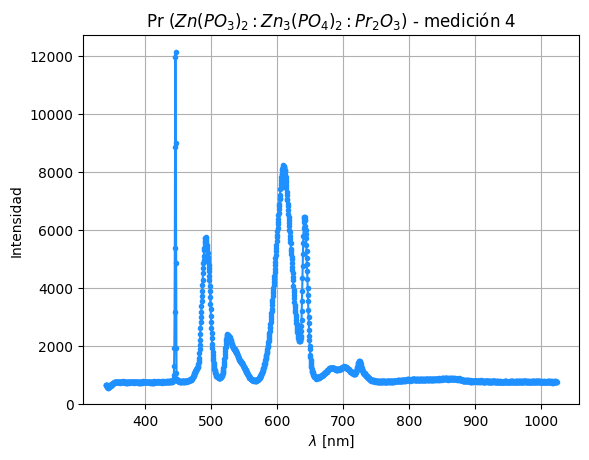

In [ ]:
plt.plot(pr_med_4_x,pr_med_4_y,'.-',c='dodgerblue')
plt.title(r'Pr ($Zn(PO_3)_2:Zn_3(PO_4)_2:Pr_2O_3$) - medición 4')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.grid()

**Calculamos cada pico**

In [ ]:
# Ubicamos el pico (1) más grande
pr_med_4_maxInt_1 = max(pr_med_4_y)
pr_med_4_pico_1 = pr_med_4_x[np.argmax(pr_med_4_y)]

print('Intensidad max 1 =',pr_med_4_maxInt_1)
print(r'Lambda max 1 =',pr_med_4_pico_1)

# Ubicamos los demás picos ajustando el rango a mano (viendo la gráfica)
# pico (2)
pr_med_4_maxInt_2 = max(pr_med_4_y[300::])
pr_med_4_pico_2 = pr_med_4_x[300 + np.argmax(pr_med_4_y[300::])]

print('Intensidad max 2 =',pr_med_4_maxInt_2)
print(r'Lambda max 2 =',pr_med_4_pico_2)

# pico (3)
pr_med_4_maxInt_3 = max(pr_med_4_y[800::])
pr_med_4_pico_3 = pr_med_4_x[800 + np.argmax(pr_med_4_y[800::])]

print('Intensidad max 3 =',pr_med_4_maxInt_3)
print(r'Lambda max 3 =',pr_med_4_pico_3)

# pico (4)
pr_med_4_maxInt_4 = max(pr_med_4_y[400:600])
pr_med_4_pico_4 = pr_med_4_x[400 + np.argmax(pr_med_4_y[400:600])]

print('Intensidad max 4 =',pr_med_4_maxInt_4)
print(r'Lambda max 4 =',pr_med_4_pico_4)

# pico (5)
pr_med_4_maxInt_5 = max(pr_med_4_y[450:650])
pr_med_4_pico_5 = pr_med_4_x[450 + np.argmax(pr_med_4_y[450:650])]

print('Intensidad max 5 =',pr_med_4_maxInt_5)
print(r'Lambda max 5 =',pr_med_4_pico_5)

# pico (6)
pr_med_4_maxInt_6 = max(pr_med_4_y[900::])
pr_med_4_pico_6 = pr_med_4_x[900 + np.argmax(pr_med_4_y[900::])]

print('Intensidad max 6 =',pr_med_4_maxInt_6)
print(r'Lambda max 6 =',pr_med_4_pico_6)

Intensidad max 1 = 12157.68
Lambda max 1 = 445.51
Intensidad max 2 = 8232.6
Lambda max 2 = 609.09
Intensidad max 3 = 6455.2
Lambda max 3 = 641.22
Intensidad max 4 = 5748.82
Lambda max 4 = 491.21
Intensidad max 5 = 2395.54
Lambda max 5 = 524.21
Intensidad max 6 = 1468.69
Lambda max 6 = 723.79


**Hacemos otra gráfica localizando estos puntos máximos para confirmar**

(<matplotlib.lines.Line2D at 0x7b84c3691950>,
 <matplotlib.lines.Line2D at 0x7b84c3691a90>)

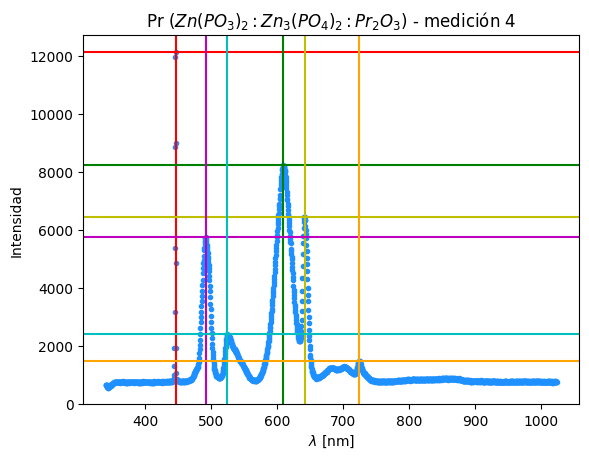

In [ ]:
plt.plot(pr_med_4_x,pr_med_4_y,'.',c='dodgerblue')
plt.title(r'Pr ($Zn(PO_3)_2:Zn_3(PO_4)_2:Pr_2O_3$) - medición 4')
plt.xlabel(r'$\lambda$ [nm]'), plt.ylabel(r'Intensidad')
plt.axvline(pr_med_4_pico_1,c='r'), plt.axhline(pr_med_4_maxInt_1,c='r') # pico (1)
plt.axvline(pr_med_4_pico_2,c='g'), plt.axhline(pr_med_4_maxInt_2,c='g') # pico (2)
plt.axvline(pr_med_4_pico_3,c='y'), plt.axhline(pr_med_4_maxInt_3,c='y') # pico (3)
plt.axvline(pr_med_4_pico_4,c='m'), plt.axhline(pr_med_4_maxInt_4,c='m') # pico (4)
plt.axvline(pr_med_4_pico_5,c='c'), plt.axhline(pr_med_4_maxInt_5,c='c') # pico (5)
plt.axvline(pr_med_4_pico_6,c='orange'), plt.axhline(pr_med_4_maxInt_6,c='orange') # pico (6)
#plt.grid()

**Ya verificados, recordamos los picos y calculamos la energía correspondiente**